In [ ]:
5 min rolling avg 
lagging rolling abg 
window should be behid current point 


In [16]:
# local data folder (repo `data/`) instead of Google Drive
from pathlib import Path

REPO = Path.cwd().resolve()
while not (REPO / 'data').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent

DATA_DIR = REPO / 'data'
print('data folder:', DATA_DIR)

data folder: /home/jovyan/ohw26_GapfillingPEARL/data


In [2]:
# checking contents of the data folder
# note: pearl10_20240517-20250131 (the single all-in-one file) is a truncated copy and
# will not open, so we use the 9 monthly files, which cover the same period.
nc_files = sorted(f for f in DATA_DIR.glob('**/*.nc')
                  if '20240517-20250131' not in f.name)
for f in nc_files:
    print(f)

/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20240517-20240531_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20240531-20240630_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20240630-20240731_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20240731-20240831_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20240831-20240930_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20240930-20241031_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20241031-20241130_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20241130-20241231_QC_clean_1min_avg.nc
/home/jovyan/ohw26_GapfillingPEARL/data/pearl10_20241231-20250131_QC_clean_1min_avg.nc


In [3]:
# seeing what all netcdfs are there and how big they are
for f in nc_files:
    print(f'{f.stat().st_size/1e6:7.1f} MB  {f.name}')


    4.4 MB  pearl10_20240517-20240531_QC_clean_1min_avg.nc
    9.1 MB  pearl10_20240531-20240630_QC_clean_1min_avg.nc
    9.4 MB  pearl10_20240630-20240731_QC_clean_1min_avg.nc
    9.4 MB  pearl10_20240731-20240831_QC_clean_1min_avg.nc
    9.1 MB  pearl10_20240831-20240930_QC_clean_1min_avg.nc
    9.4 MB  pearl10_20240930-20241031_QC_clean_1min_avg.nc
    9.1 MB  pearl10_20241031-20241130_QC_clean_1min_avg.nc
    9.4 MB  pearl10_20241130-20241231_QC_clean_1min_avg.nc
    9.3 MB  pearl10_20241231-20250131_QC_clean_1min_avg.nc


In [4]:
# vars in the cleaned 1_min_avg dataset (excluding the skip array vars)
# monthly files stitched together into one continuous minute series
import netCDF4 as nc
import numpy as np
import pandas as pd

FILES = nc_files
skip = ['time', 'time_epoch', 'time_string_utc', 'latitude', 'longitude', 'depth']

parts = []
for f in FILES:
    d = nc.Dataset(f)
    time = pd.to_datetime(np.asarray(d['time'][:]).astype(float), unit='s')
    cols = [v for v in d.variables if v not in skip]
    parts.append(pd.DataFrame(
        {v: np.ma.filled(d[v][:], np.nan).astype(float) for v in cols},
        index=time
    ))
    d.close()

df = pd.concat(parts).sort_index()
df = df[~df.index.duplicated(keep='first')]          # months overlap on their shared edge
df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq='1min'))

print(df.shape)
print(df.index.min(), '->', df.index.max())
df.head()


(373292, 14)
2024-05-17 13:34:00 -> 2025-01-31 19:05:00


,tsg_temp_c,salinity_psu,o2_mll,o2_umol_l_derived,chl_695_counts,bb_470_counts,bb_700_counts,flow_lpm,par_umol_m2_s1,wind_speed_ms,wind_dir_raw_deg,air_temp_c,rh_pct,pressure_hpa
2024-05-17 13:34:00,13.078229,30.391400,7.495200,334.743127,71.142857,555.285714,56.285714,3.564396,79.900015,0.677143,248.571429,5.60,90.142857,1017.20
2024-05-17 13:35:00,13.079500,30.349963,7.524857,336.067645,70.600000,552.200000,56.200000,3.550687,80.540897,0.256000,161.800000,5.60,90.300000,1017.20
2024-05-17 13:36:00,13.043156,30.269033,7.571143,338.134811,69.900000,546.600000,56.000000,2.734988,80.540897,0.390000,159.000000,5.60,89.285714,1017.20
2024-05-17 13:37:00,13.035110,30.267260,7.541143,336.794981,69.600000,547.600000,56.000000,3.646651,80.989514,0.460000,127.100000,5.63,89.500000,1017.26
2024-05-17 13:38:00,13.018160,30.184220,7.567111,337.954749,69.500000,550.100000,56.300000,3.214811,83.232600,0.745000,71.200000,5.66,89.700000,1017.30


## CHINA CREEK DATASET

In [5]:
url = 'https://dap.oceannetworks.ca/erddap/tabledap/scalar_1214374.csv?timeseries_id%2Ctime%2Csalinity%2CTemperature%2Clatitude%2Clongitude%2Cdepth&time%3E=2024-08-06&time%3C=2025-01-31'
print(f"Querying data from: {url}")

response = requests.get(url, verify=False)
response.raise_for_status()

data = pd.read_csv(io.StringIO(response.text))

# The first row of an ERDDAP CSV response contains the units
units = data.iloc[0]
data_values = data.iloc[1:].copy()

# Convert time column to datetime objects
data_values['time'] = pd.to_datetime(data_values['time'])
data_values['temperature'] = pd.to_numeric(data_values['temperature']) - 273.15 # convert from K to celsius
data_values['salinity'] = pd.to_numeric(data_values['salinity'])

Querying data from: https://dap.oceannetworks.ca/erddap/tabledap/scalar_1214374.csv?timeseries_id%2Ctime%2Csalinity%2CTemperature%2Clatitude%2Clongitude%2Cdepth&time%3E=2024-08-06&time%3C=2025-01-31


NameError: name 'requests' is not defined

In [11]:
# =====================================================================
# CHINA CREEK (ONC scalar_1214374) -> hourly, same treatment as `dfh`.
#
# The raw feed is 1 Hz, so Aug-Jan is ~15M rows. Instead of pulling that
# and averaging locally, ERDDAP bins it server-side with
# orderByMean("time/5minutes") -> ~52k rows, ~2 min total.
#
# ERDDAP labels each bin at its START, so the bin labelled 23:55 is the
# mean of 23:55-00:00 - exactly the 5 min BEHIND the hour, which is what
# rolling('5min') gives at 00:00. Shift the labels +5 min and the
# on-the-hour rows are the lagging 5-min average, same as dfh.
# =====================================================================
import requests, io, urllib3
import pandas as pd
urllib3.disable_warnings()

base = 'https://dap.oceannetworks.ca/erddap/tabledap/scalar_1214374.csv'
qv   = 'time,salinity,Temperature'

# month-at-a-time so no single request stalls
edges = [pd.Timestamp('2024-08-06')] + list(pd.date_range('2024-09-01', '2025-02-01', freq='MS'))

parts = []
for a, b in zip(edges[:-1], edges[1:]):
    url = (f'{base}?{qv}&time>={a:%Y-%m-%d}&time<{b:%Y-%m-%d}'
           f'&orderByMean("timedfhc = dfhc[dfhc[CC_COLS].notna().all(axis=1) | dfhc[CC_COLS].isna().all(axis=1)]/5minutes")')
    r = requests.get(url, verify=False, timeout=600)
    r.raise_for_status()
    d = pd.read_csv(io.StringIO(r.text)).iloc[1:]
    d['time'] = pd.to_datetime(d['time']).dt.tz_localize(None) 
    d['cc_temp_c']   = pd.to_numeric(d['Temperature']) - 273.15 
    d['cc_salinity'] = pd.to_numeric(d['salinity'])
    parts.append(d.set_index('time')[['cc_temp_c', 'cc_salinity']])
    print(f'{a:%Y-%m-%d} -> {b:%Y-%m-%d}: {len(d)} bins')

cc5 = pd.concat(parts).sort_index()
cc5 = cc5[~cc5.index.duplicated(keep='first')]

# bin labelled 23:55 = mean over 23:55-00:00 = the 5 min behind 00:00
cc5.index = cc5.index + pd.Timedelta('5min')

# keep the on-the-hour rows; empty bins are absent from the ERDDAP
# response, so real gaps stay NaN instead of being invented
hourly = pd.date_range(cc5.index.min().ceil('1h'), cc5.index.max().floor('1h'), freq='1h')
cch = cc5.reindex(hourly)

print(cch.shape, '|', cch.index.min(), '->', cch.index.max())
print('valid:', cch.notna().mean().round(3).to_dict())
cch.head()


2024-08-06 -> 2024-09-01: 7488 bins
2024-09-01 -> 2024-10-01: 8640 bins
2024-10-01 -> 2024-11-01: 8928 bins
2024-11-01 -> 2024-12-01: 8622 bins
2024-12-01 -> 2025-01-01: 8626 bins
2025-01-01 -> 2025-02-01: 8928 bins
(4296, 2) | 2024-08-06 01:00:00 -> 2025-02-01 00:00:00
valid: {'cc_temp_c': 0.994, 'cc_salinity': 0.994}


NameError: name 'dfh' is not defined

In [18]:
CC_COLS = ['cc_temp_c', 'cc_salinity']

dfhc = dfh.drop(columns=CC_COLS, errors='ignore').join(cch.reindex(dfh.index))

print(f'{dfhc.shape[0]} hourly rows, {dfhc.shape[1]} columns')
print('CC coverage:', dfhc[CC_COLS].notna().mean().round(3).to_dict())

373292 hourly rows, 16 columns
CC coverage: {'cc_temp_c': 0.011, 'cc_salinity': 0.011}


In [19]:
dfhc = dfhc[dfhc[CC_COLS].notna().all(axis=1) | dfhc[CC_COLS].isna().all(axis=1)]

In [20]:
print('CC available while PEARL temp is missing:',
      f"{100*dfhc.loc[dfhc.tsg_temp_c.isna(), 'cc_temp_c'].notna().mean():.1f}%")

CC available while PEARL temp is missing: 0.7%


In [21]:
dfhc = dfhc[dfhc[CC_COLS].notna().all(axis=1)]

<Axes: >

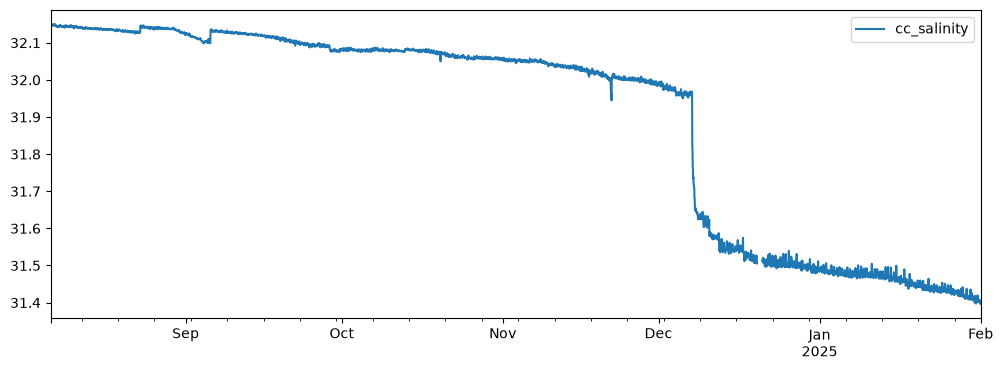

In [15]:
cch.plot(y='cc_salinity', figsize=(12,4))

<Axes: >

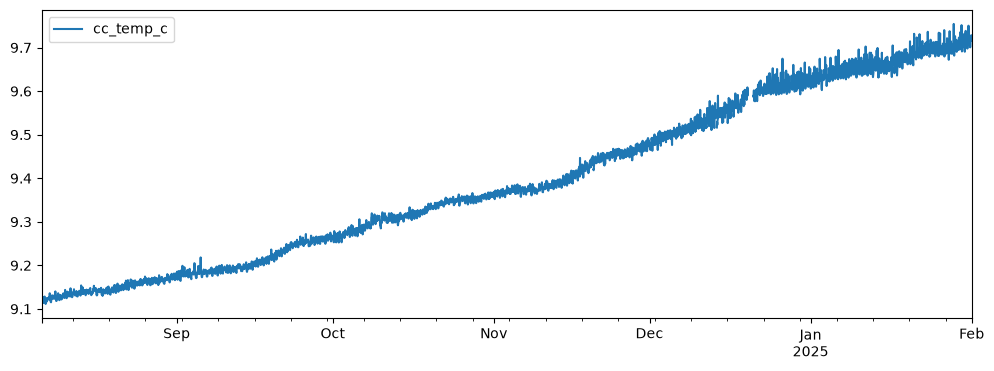

In [16]:
cch.plot(y='cc_temp_c', figsize=(12,4))

In [33]:
# there is a 21-day, 19-hr gap: last good point 2024-07-15 07:56, data resumes 2024-08-06 03:41.
# cut everything before that so every plot/model below only sees the continuous stretch.
# (re-run the loading cell above if you ever want the full record back)
# START = '2024-08-06'
# df = df.loc[START:]

print(df.index.min(), '->', df.index.max(), '|', df.shape)
print('valid tsg_temp_c:', round(df['tsg_temp_c'].notna().mean() * 100, 1), '%')


2024-05-17 13:34:00 -> 2025-01-31 19:05:00 | (373292, 14)
valid tsg_temp_c: 83.0 %


<Axes: >

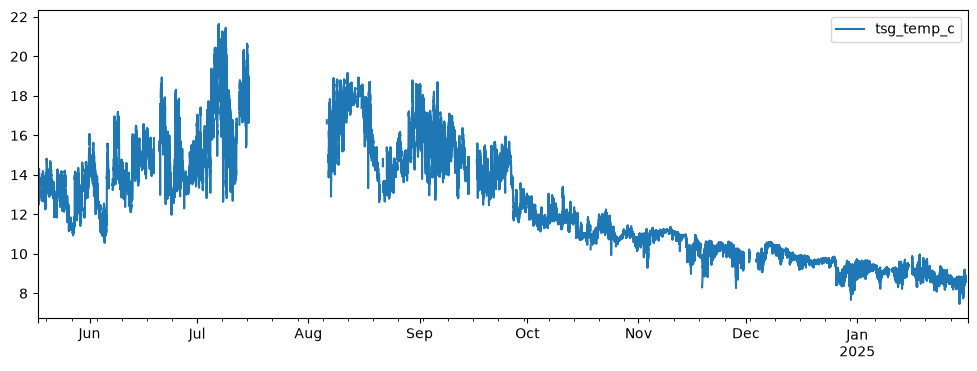

In [34]:
df.plot(y='tsg_temp_c', figsize=(12, 4))

<Axes: >

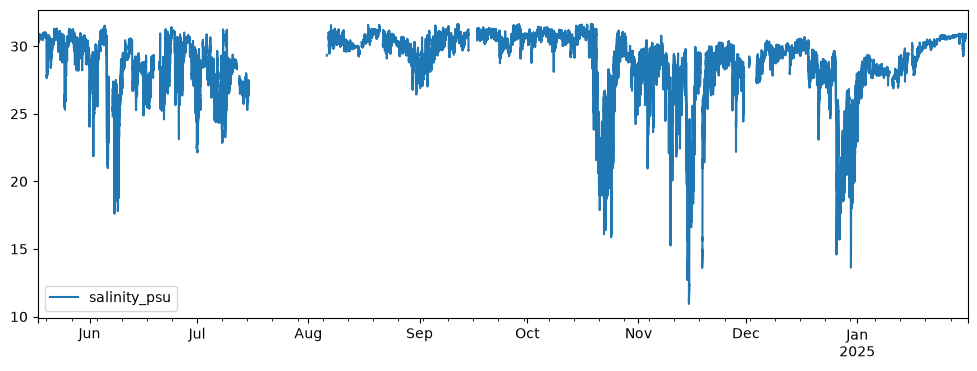

In [35]:
df.plot(y='salinity_psu', figsize=(12, 4))

In [21]:
# hourly version of df: 5-min LAGGING rolling mean, then keep the value on each hour
# rolling('5min') is trailing by default -> each value only uses the 5 min behind it
# min_periods=3 so a mostly-empty window doesn't turn into a fake number
# asfreq('1h') just picks the on-the-hour rows, so real gaps stay NaN
dfh = df.rolling('5min', min_periods=3).mean().asfreq('1h')

print(df.shape, '->', dfh.shape)
dfh.head()


(257466, 14) -> (4292, 14)


,tsg_temp_c,salinity_psu,o2_mll,o2_umol_l_derived,chl_695_counts,bb_470_counts,bb_700_counts,flow_lpm,par_umol_m2_s1,wind_speed_ms,wind_dir_raw_deg,air_temp_c,rh_pct,pressure_hpa
2024-08-06 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-06 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-06 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-06 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-06 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.27598,1.234911,124.285079,14.508921,86.785714,1017.002


<Axes: title={'center': 'hourly (5-min lagging avg)'}>

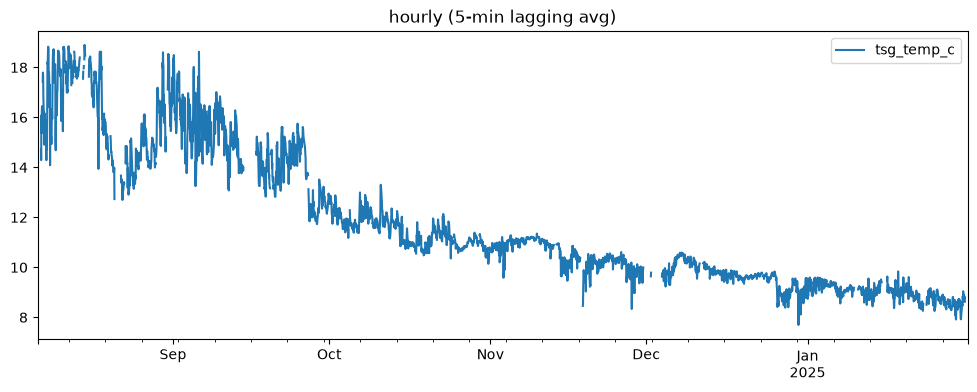

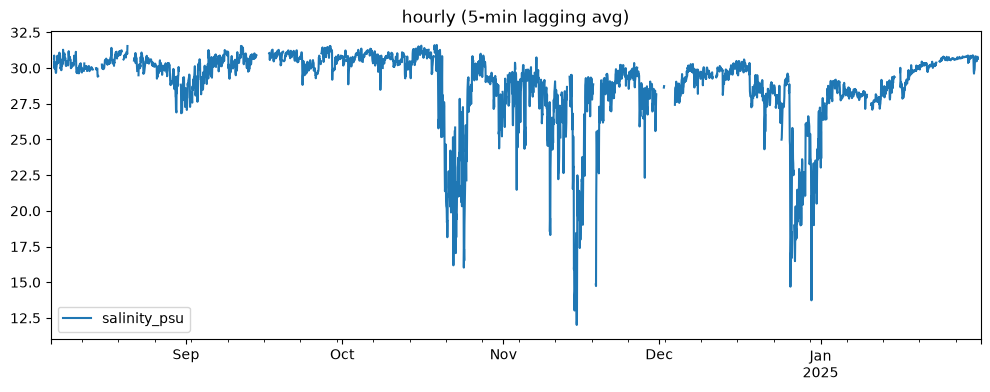

In [22]:
dfh.plot(y='tsg_temp_c', figsize=(12, 4), title='hourly (5-min lagging avg)')
dfh.plot(y='salinity_psu', figsize=(12, 4), title='hourly (5-min lagging avg)')


In [18]:
%pip install pygam

Note: you may need to restart the kernel to use updated packages.


In [22]:
# =====================================================================
# GAM gap-filler.  One entry point (`run_gapfill`) built from small
# helpers, so the same code works on the per-minute frame and on the
# hourly frame - the only difference is `freq_min`.
#
# What it does, unchanged from before:
#   - punch fake gaps of known length into clean stretches of real data
#   - describe each missing point by where it sits in the gap, what the
#     signal was doing on either side, and the drivers at that moment
#   - fit a GAM to the RESIDUAL from a straight line across the gap,
#     taper that correction to zero at both edges, and score it against
#     the straight line
#   - split train/test by 2-week BLOCKS so a gap's neighbours can never
#     leak into training
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s

# ---- knobs ----------------------------------------------------------
GAPS_MIN    = (10, 60, 360, 720, 1440, 2880)   # gap lengths to fake, in MINUTES
BLOCK_DAYS  = 14        # train/test split unit, in days
MIN_BLOCKS  = 4         # fewest blocks a run is allowed to score on
SEEDS       = (0, 1, 2, 3, 4)
N_GAPS      = 150       # fake gaps per (length, seed)
MAX_ROWS    = 60        # rows kept per gap (long gaps get subsampled)
PAD_MIN     = 180       # clean data required either side of a fake gap
SLOPE_LAG   = 10        # steps used for the b_slope / a_slope features
TRAIN_FRAC  = 0.7
LAM         = 1000      # GAM smoothing penalty - the anti-overfit knob
SHORT_MAX_MIN = 60      # gaps this short also get the fine local features
MIN_COVER   = 0.5       # drop a driver that is missing more than half the time

SHAPE_COLS = ['pos_frac', 'dist_edge', 'b_slope', 'a_slope']
LOCAL_COLS = ['b_d1', 'b_d2', 'a_d1', 'a_d2', 'b_curv', 'a_curv']
CYCLIC     = {'hour', 'doy'}
# drivers also fed in as CHANGE since the last real point before the gap.
# for a second sensor in the same inlet that delta is the whole point:
# "the other site rose 0.4 psu across this window" is transferable in a way
# that its absolute level is not.
DELTA      = ('airt', 'tide', 'cc_temp', 'cc_sal')
C = dict(truth='#52514e', lin='#2a78d6', gam='#eb6834', gap='#b9b5ac')


# ---- helpers --------------------------------------------------------
def build_drivers(frame):
    """External predictors, as (names, matrix). Anything absent from the
    frame or missing more than half the time is quietly dropped."""
    get = lambda c: frame[c].values.astype(float) if c in frame.columns else None
    ws = get('wind_speed_ms')
    wd = get('wind_dir_raw_deg')
    wd = np.deg2rad(wd) if wd is not None else None

    cand = {
        'hour':   frame.index.hour.values + frame.index.minute.values / 60,
        'doy':    frame.index.dayofyear.values.astype(float),
        'tide':   get('tide_m'),
        'airt':   get('air_temp_c'),
        'wind':   ws,
        # wind as a vector, so 359 deg and 1 deg are neighbours
        'wind_u': ws * np.sin(wd) if (ws is not None and wd is not None) else None,
        'wind_v': ws * np.cos(wd) if (ws is not None and wd is not None) else None,
        'press':  get('pressure_hpa'),
        'par':    get('par_umol_m2_s1'),
        'rh':     get('rh_pct'),
        # China Creek (ONC scalar_1214374), pulled hourly in the cell above
        'cc_temp': get('cc_temp_c'),
        'cc_sal':  get('cc_salinity'),
    }
    names, cols, dropped = [], [], []
    for n, v in cand.items():
        if v is None:
            dropped.append(f'{n} (no column)')
        elif np.isfinite(v).mean() < MIN_COVER:
            dropped.append(f'{n} ({100*np.isfinite(v).mean():.0f}% present)')
        else:
            names.append(n); cols.append(v.astype(float))
    if dropped:
        print('  drivers skipped:', ', '.join(dropped))
    return names, np.column_stack(cols)


def gap_rows(fit, i, G, ks):
    """One row per missing step of a fake gap that starts at index `i`
    and is `G` steps long. `ks` picks which steps inside it to keep."""
    y, ext, en = fit.y, fit.ext, fit.driver_names
    b_last, a_first = y[i - 1], y[i + G]
    j = i + ks
    out = pd.DataFrame({
        'pos_frac':  (ks + 1) / (G + 1),                 # 0..1 across the gap
        'dist_edge': np.minimum(ks + 1, G - ks),         # steps to nearest edge
        'b_slope':   y[i - 1] - y[i - SLOPE_LAG],        # trend going in
        'a_slope':   y[i + G + SLOPE_LAG - 1] - y[i + G],  # trend coming out
        'b_d1': y[i-1] - y[i-2],   'b_d2': y[i-2] - y[i-3],
        'a_d1': y[i+G+1] - y[i+G], 'a_d2': y[i+G+2] - y[i+G+1],
        'b_curv': y[i-1] - 2*y[i-2] + y[i-3],
        'a_curv': y[i+G+2] - 2*y[i+G+1] + y[i+G],
        'linear_guess': np.interp(ks + 1, [0, G + 1], [b_last, a_first]),
        'truth': y[j],
    })
    for k, n in enumerate(en):
        out[n] = ext[j, k]
    # drivers as CHANGE since the last real point, not absolute level
    for n in DELTA:
        if n in en:
            out['d_' + n] = out[n] - ext[i - 1, en.index(n)]
    return out


def feature_cols(fit, G_min):
    """Short gaps get the fine local shape features; long gaps don't -
    at 2 days out, what the signal did 3 minutes before the gap is noise.

    Only `fit.use_names` become features. Anything else still has to be
    present for a fake gap to be eligible, so switching the driver list
    on and off compares the SAME gaps - otherwise the two runs would be
    scored on different holes and the difference would mean nothing."""
    drivers = fit.use_names + [f'd_{c}' for c in DELTA if c in fit.use_names]
    return SHAPE_COLS + (LOCAL_COLS if G_min <= SHORT_MAX_MIN else []) + drivers


def build_terms(fit, cols):
    """s() per feature, cyclic basis for hour-of-day and day-of-year."""
    terms = None
    for k, c in enumerate(cols):
        try:
            t = s(k, basis='cp') if c in CYCLIC else s(k)
        except Exception:
            t = s(k)
        terms = t if terms is None else terms + t
    return terms


def sample_starts(fit, G, rng, n):
    """Random start indices whose gap + padding is entirely clean data
    and sits inside a single block."""
    starts, tries = [], 0
    lo, hi = fit.pad, len(fit.y) - G - fit.pad
    while len(starts) < n and tries < n * 400 and hi > lo:
        tries += 1
        i = int(rng.integers(lo, hi))
        if fit.block[i] != fit.block[i + G - 1]:
            continue
        w = slice(i - fit.pad, i + G + fit.pad)
        if not (fit.y_ok[w].all() and fit.ext_ok[w].all()):
            continue
        starts.append(i)
    return starts


def taper(pos_frac):
    """1 in the middle, 0 at both edges - the GAM is only allowed to bend
    the line, never to move its endpoints."""
    return 2 * np.minimum(pos_frac, 1 - pos_frac)


def one_run(fit, G_min, seed):
    """Fit + score one (gap length, seed). None if there isn't enough
    clean data to do it honestly."""
    G = G_min // fit.freq_min
    rng = np.random.default_rng(seed)
    starts = sample_starts(fit, G, rng, N_GAPS)
    if len(starts) < 8:
        return None

    frames = []
    for gid, i in enumerate(starts):
        ks = (np.arange(G) if G <= MAX_ROWS
              else np.sort(rng.choice(G, MAX_ROWS, replace=False)))
        f = gap_rows(fit, i, G, ks)
        f['gap'], f['block'], f['start'] = gid, fit.block[i], i
        frames.append(f)

    cols = feature_cols(fit, G_min)
    ex = (pd.concat(frames, ignore_index=True)
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=cols + ['truth', 'linear_guess']))

    blocks = np.unique(ex.block.values)
    if len(blocks) < fit.min_blocks:
        return None
    rng.shuffle(blocks)
    tr_b = set(blocks[:max(1, round(TRAIN_FRAC * len(blocks)))])
    tr, te = ex[ex.block.isin(tr_b)], ex[~ex.block.isin(tr_b)]
    if len(tr) < 200 or len(te) < 100:
        return None

    gam = LinearGAM(build_terms(fit, cols), lam=LAM).fit(
        tr[cols].values, (tr.truth - tr.linear_guess).values)
    te = te.assign(pred=te.linear_guess.values
                        + gam.predict(te[cols].values) * taper(te.pos_frac.values))

    rmse = lambda a: float(np.sqrt(np.mean((te.truth.values - a) ** 2)))
    rec = dict(gap_min=G_min, seed=seed, n_gaps=len(starts), src_blocks=len(blocks),
               te_blocks=len(blocks) - len(tr_b), n_test=len(te),
               linear=rmse(te.linear_guess.values), gam=rmse(te.pred.values),
               sd_truth=float(te.groupby('gap').truth.std().mean()),
               sd_lin=float(te.groupby('gap').linear_guess.std().mean()),
               sd_gam=float(te.groupby('gap').pred.std().mean()))
    return rec, gam, cols, te['start'].unique()


def summarise(recs):
    """Average over seeds, and call an improvement real only if it is
    bigger than the seed-to-seed wobble of both methods."""
    r = pd.DataFrame(recs)
    a = r.groupby('gap_min').agg(
        seeds=('seed', 'size'), gaps=('n_gaps', 'mean'),
        src_blk=('src_blocks', 'mean'), test_blk=('te_blocks', 'mean'),
        linear=('linear', 'mean'), lin_sd=('linear', 'std'),
        gam=('gam', 'mean'), gam_sd=('gam', 'std'),
        sd_truth=('sd_truth', 'mean'), sd_lin=('sd_lin', 'mean'),
        sd_gam=('sd_gam', 'mean'))
    a['improve_%'] = (100 * (a.linear - a.gam) / a.linear).round(1)
    a['real?'] = np.where((a.linear - a.gam).abs() > (a.lin_sd + a.gam_sd).fillna(0),
                          'yes', 'NO - noise')
    return a


class GapFillFit:
    """The result of a run: the data it was fit on, one model per gap
    length, and the scoreboard. Everything the plots need lives here."""

    def __init__(self, frame, target, freq_min,
                 block_days=BLOCK_DAYS, min_blocks=MIN_BLOCKS, use_drivers=None):
        self.target, self.freq_min = target, freq_min
        self.block_days, self.min_blocks = block_days, min_blocks
        self.index = frame.index
        self.y = frame[target].values.astype(float)
        self.driver_names, self.ext = build_drivers(frame)
        # every available driver gates eligibility through ext_ok below;
        # use_drivers picks which of them the GAM is allowed to see
        self.use_names = (list(self.driver_names) if use_drivers is None else
                          [n for n in self.driver_names if n in use_drivers])
        self.y_ok = ~np.isnan(self.y)
        self.ext_ok = ~np.isnan(self.ext).any(axis=1)
        self.pad = max(int(np.ceil(PAD_MIN / freq_min)), SLOPE_LAG + 2)
        self.block = np.arange(len(frame)) // max(1, block_days * 24 * 60 // freq_min)
        self.models, self.summary = {}, pd.DataFrame()

    def fill(self, gap_min, i):
        """Fill one gap end to end. -> (times, truth, linear, gam)"""
        gam, cols, _ = self.models[gap_min]
        G = gap_min // self.freq_min
        f = gap_rows(self, i, G, np.arange(G))
        pred = f.linear_guess.values + gam.predict(f[cols].values) * taper(f.pos_frac.values)
        return self.index[i:i + G], f.truth.values, f.linear_guess.values, pred


# ---- entry point ----------------------------------------------------
def run_gapfill(frame, target='salinity_psu', gaps_min=GAPS_MIN,
                start=None, freq_min=None, seeds=SEEDS,
                block_days=BLOCK_DAYS, min_blocks=MIN_BLOCKS,
                use_drivers=None, quiet=False):
    """Fit + score the gap-filler on `frame`.

    frame     : dataframe on a regular time index (per-minute or hourly)
    target    : column to gap-fill
    gaps_min  : gap lengths to fake, IN MINUTES - the same numbers work
                for both frames; lengths shorter than one step are skipped
    start     : optional date to cut the record at (e.g. after the big gap)
    freq_min  : spacing of the index in minutes; inferred if not given
    block_days: size of the train/test split unit. BIGGER = stricter test
                (train and test sit further apart in time, so the model
                can't lean on "same week, same conditions" recall), but
                fewer blocks means a noisier, more seasonal score
    use_drivers: names of the drivers the GAM may use. None = all of them.
                Drivers left out still have to be present for a fake gap to
                count, so two runs with different lists are scored on the
                same gaps - that is what makes an A/B honest
    min_blocks: fewest blocks a gap length needs before it is scored.
                A long block_days needs this lowered - 90-day blocks on a
                6-month record only give you 2
    """
    D = frame.loc[start:] if start else frame
    if freq_min is None:
        freq_min = int(round(pd.Series(D.index).diff().median().total_seconds() / 60))

    if not quiet:
        print(f'{target}: {len(D)*freq_min/1440:.0f} days at {freq_min} min '
              f'({len(D)} rows)')
    fit = GapFillFit(D, target, freq_min, block_days, min_blocks, use_drivers)
    n_blk = fit.block.max() + 1
    if not quiet:
        print(f'  drivers used: {", ".join(fit.use_names)}')
        held = [n for n in fit.driver_names if n not in fit.use_names]
        if held:
            print(f'  drivers withheld from the model, but still required '
                  f'present: {", ".join(held)}')
        print(f'  {n_blk} blocks of {block_days} days '
              f'(need {min_blocks} to score), pad {fit.pad} steps, lam {LAM}')
    if n_blk < min_blocks:
        print(f'  !! only {n_blk} blocks exist but min_blocks={min_blocks} - '
              f'everything will skip. Lower min_blocks or block_days.')

    recs = []
    for G_min in gaps_min:
        if G_min < freq_min:
            if not quiet:
                print(f'  gap {G_min:5d} min: shorter than one step - skipped')
            continue
        for sd in seeds:
            out = one_run(fit, G_min, sd)
            if out is None:
                if sd == seeds[0] and not quiet:
                    print(f'  gap {G_min:5d} min: not enough clean stretches, or '
                          f'they span fewer than {fit.min_blocks} blocks - skipped')
                continue
            recs.append(out[0])
            fit.models.setdefault(G_min, out[1:])

    if not recs:
        print('nothing to report'); return fit

    fit.summary = summarise(recs)
    a = fit.summary
    print('\nACCURACY  (RMSE, mean over seeds; lower is better)')
    print(a[['seeds', 'gaps', 'src_blk', 'test_blk', 'linear', 'lin_sd',
             'gam', 'gam_sd', 'improve_%', 'real?']].round(4).to_string())
    print('\nSPREAD    (within-gap std; ratio 1.00 = same wiggle as reality)')
    sp = a[['sd_truth', 'sd_lin', 'sd_gam']].copy()
    sp['lin_ratio'] = (a.sd_lin / a.sd_truth).round(2)
    sp['gam_ratio'] = (a.sd_gam / a.sd_truth).round(2)
    print(sp.round(4).to_string())
    return fit


# ---- plots ----------------------------------------------------------
def plot_overview(fit, ax):
    """Whole record with the real gaps shaded."""
    miss = ~fit.y_ok
    ax.plot(fit.index, fit.y, lw=0.4, color=C['truth'])
    e = np.diff(np.concatenate([[0], miss.astype(int), [0]]))
    span = max(1, 60 // fit.freq_min)          # shade real gaps of 1 h or more
    for s0, e0 in zip(np.where(e == 1)[0], np.where(e == -1)[0]):
        if e0 - s0 >= span:
            ax.axvspan(fit.index[s0], fit.index[min(e0, len(fit.index) - 1)],
                       color=C['gap'], alpha=0.75, lw=0)
    ax.set_title(f'{fit.target} - shaded = real gaps of 1 hour or more '
                 f'({100*miss.mean():.0f}% of steps missing)', loc='left', fontsize=11)
    ax.set_ylabel(fit.target)


def plot_examples(fit, gap_min, ax, n_examples=4):
    """Several held-out gaps of one length, side by side on a fake
    x-axis (they come from different points in the record)."""
    G = gap_min // fit.freq_min
    starts = [int(i) for i in fit.models[gap_min][2][:n_examples]]
    ctx, offset = max(20 // fit.freq_min, G // 4, 5), 0

    for n, i in enumerate(starts):
        t, truth, lin, gam = fit.fill(gap_min, i)
        seg = fit.y[i - ctx: i + G + ctx]
        x = np.arange(len(seg)) + offset
        xg = x[ctx:ctx + G]
        ax.axvspan(xg[0], xg[-1], color=C['gap'], alpha=0.45, lw=0, zorder=0)
        ax.plot(x, seg, lw=1.0, color=C['truth'], zorder=3,
                label='real data' if n == 0 else None)
        ax.plot(xg, lin, lw=1.8, color=C['lin'], zorder=4,
                label='linear fill' if n == 0 else None)
        ax.plot(xg, gam, lw=1.8, color=C['gam'], zorder=5,
                label='GAM fill' if n == 0 else None)
        ax.text(xg[0], ax.get_ylim()[1], fit.index[i].strftime('%b %d'),
                fontsize=7, color=C['truth'], va='top', ha='left')
        offset += len(seg) + max(10, G // 6)

    lbl = f'{gap_min} min' if gap_min < 1440 else f'{gap_min//1440} day'
    title = f'{lbl} gaps - {len(starts)} held-out examples'
    if gap_min in fit.summary.index:
        r = fit.summary.loc[gap_min]
        title += (f'   |   over all seeds: linear {r.linear:.3f}, '
                  f'GAM {r.gam:.3f}  ({r["improve_%"]:+.0f}%)')
    ax.set_title(title, loc='left', fontsize=10)
    ax.set_ylabel(fit.target, fontsize=9)
    ax.set_xticks([])
    ax.grid(alpha=0.2, lw=0.5, axis='y')
    for sp_ in ('top', 'right', 'bottom'):
        ax.spines[sp_].set_visible(False)


def plot_gapfill(fit, gaps_min=None, n_examples=4, note=''):
    """Overview panel on top, then one panel per gap length."""
    show = [G for G in (gaps_min or fit.models.keys()) if G in fit.models]
    if not show:
        print('no fitted models to plot'); return
    fig, axes = plt.subplots(1 + len(show), 1,
                             figsize=(14, 3.2 + 2.6 * len(show)), squeeze=False)
    axes = axes[:, 0]
    plot_overview(fit, axes[0])
    for ax, G in zip(axes[1:], show):
        plot_examples(fit, G, ax, n_examples)
    axes[1].legend(loc='upper right', frameon=False, fontsize=8, ncol=3)
    axes[0].grid(alpha=0.25, lw=0.5)
    for sp_ in ('top', 'right'):
        axes[0].spines[sp_].set_visible(False)
    fig.suptitle(f'{fit.target}: how each gap length gets filled '
                 f'({fit.freq_min} min data, {fit.block_days}-day blocks{note})'
                 f'  -  grey = the hole',
                 fontsize=12, x=0.01, ha='left')
    fig.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()


salinity_psu: 179 days at 1 min (257466 rows)
  drivers skipped: tide (no column)
  drivers used: hour, doy, airt, wind, wind_u, wind_v, press, par, rh
  13 blocks of 14 days, pad 180 steps, lam 1000

ACCURACY  (RMSE, mean over seeds; lower is better)
         seeds   gaps  src_blk  test_blk  linear  lin_sd     gam  gam_sd  improve_%       real?
gap_min                                                                                        
10           3  150.0  13.0000       4.0  0.1862  0.0554  0.2001  0.0504       -7.4  NO - noise
60           3  150.0  13.0000       4.0  0.2727  0.1287  0.3915  0.2997      -43.6  NO - noise
360          3  150.0  13.0000       4.0  0.6557  0.4153  0.7886  0.3655      -20.3  NO - noise
720          3  150.0  13.0000       4.0  0.5879  0.2347  0.6546  0.2152      -11.3  NO - noise
1440         3  150.0  12.3333       4.0  1.1446  0.2686  1.1653  0.2684       -1.8  NO - noise
2880         3  150.0   8.0000       2.0  2.8721  1.7008  3.0495  1.5977    

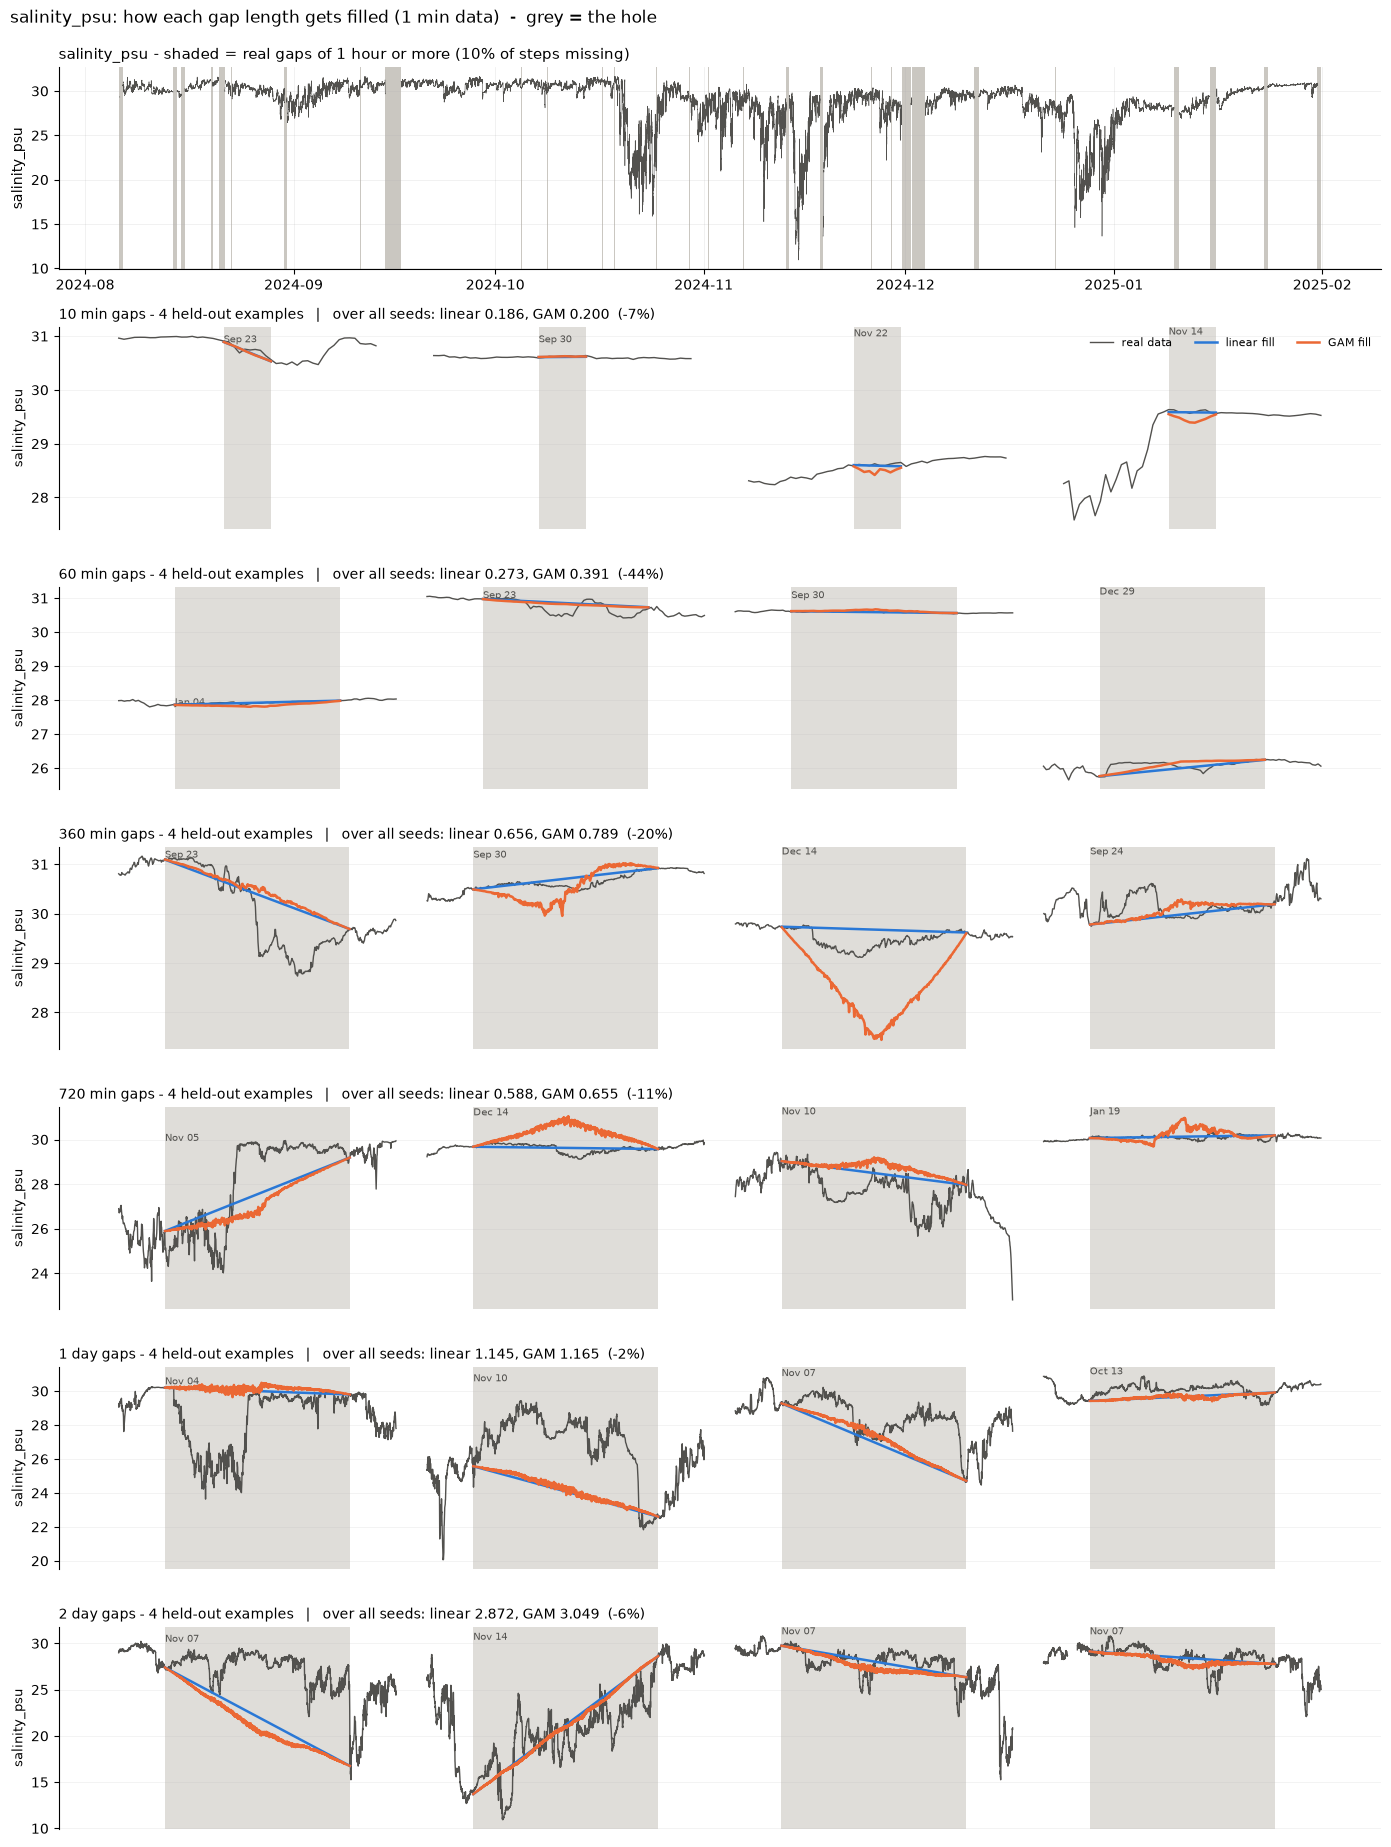

In [24]:
# =====================================================================
# PER-MINUTE gap fill.  `gaps_min` is the list of fake gap lengths to
# test - change it to whatever you want to see.
# (df has no tide_m here; if you join the tide series it gets picked up
#  automatically, no code change needed.)
# =====================================================================
fit_min = run_gapfill(df, target='salinity_psu',
                      gaps_min=(10, 60, 360, 720, 1440, 2880),
                      seeds=(0, 1, 2))

plot_gapfill(fit_min, n_examples=4)


tsg_temp_c: 179 days at 60 min (4292 rows)
  drivers skipped: tide (no column)
  drivers used: hour, doy, airt, wind, wind_u, wind_v, press, par, rh
  13 blocks of 14 days, pad 12 steps, lam 1000
  gap    10 min: shorter than one step - skipped
  gap    60 min: not enough clean stretches - skipped

ACCURACY  (RMSE, mean over seeds; lower is better)
         seeds   gaps  src_blk  test_blk  linear  lin_sd     gam  gam_sd  improve_%       real?
gap_min                                                                                        
360          3  150.0  13.0000       4.0  0.2987  0.1648  0.3001  0.1723       -0.5  NO - noise
720          3  150.0  13.0000       4.0  0.3085  0.1057  0.3073  0.0806        0.4  NO - noise
1440         3  150.0  12.6667       4.0  0.5091  0.0814  0.3996  0.0406       21.5  NO - noise
2880         3  150.0  12.0000       4.0  0.6156  0.3035  0.6000  0.2772        2.5  NO - noise

SPREAD    (within-gap std; ratio 1.00 = same wiggle as reality)
        

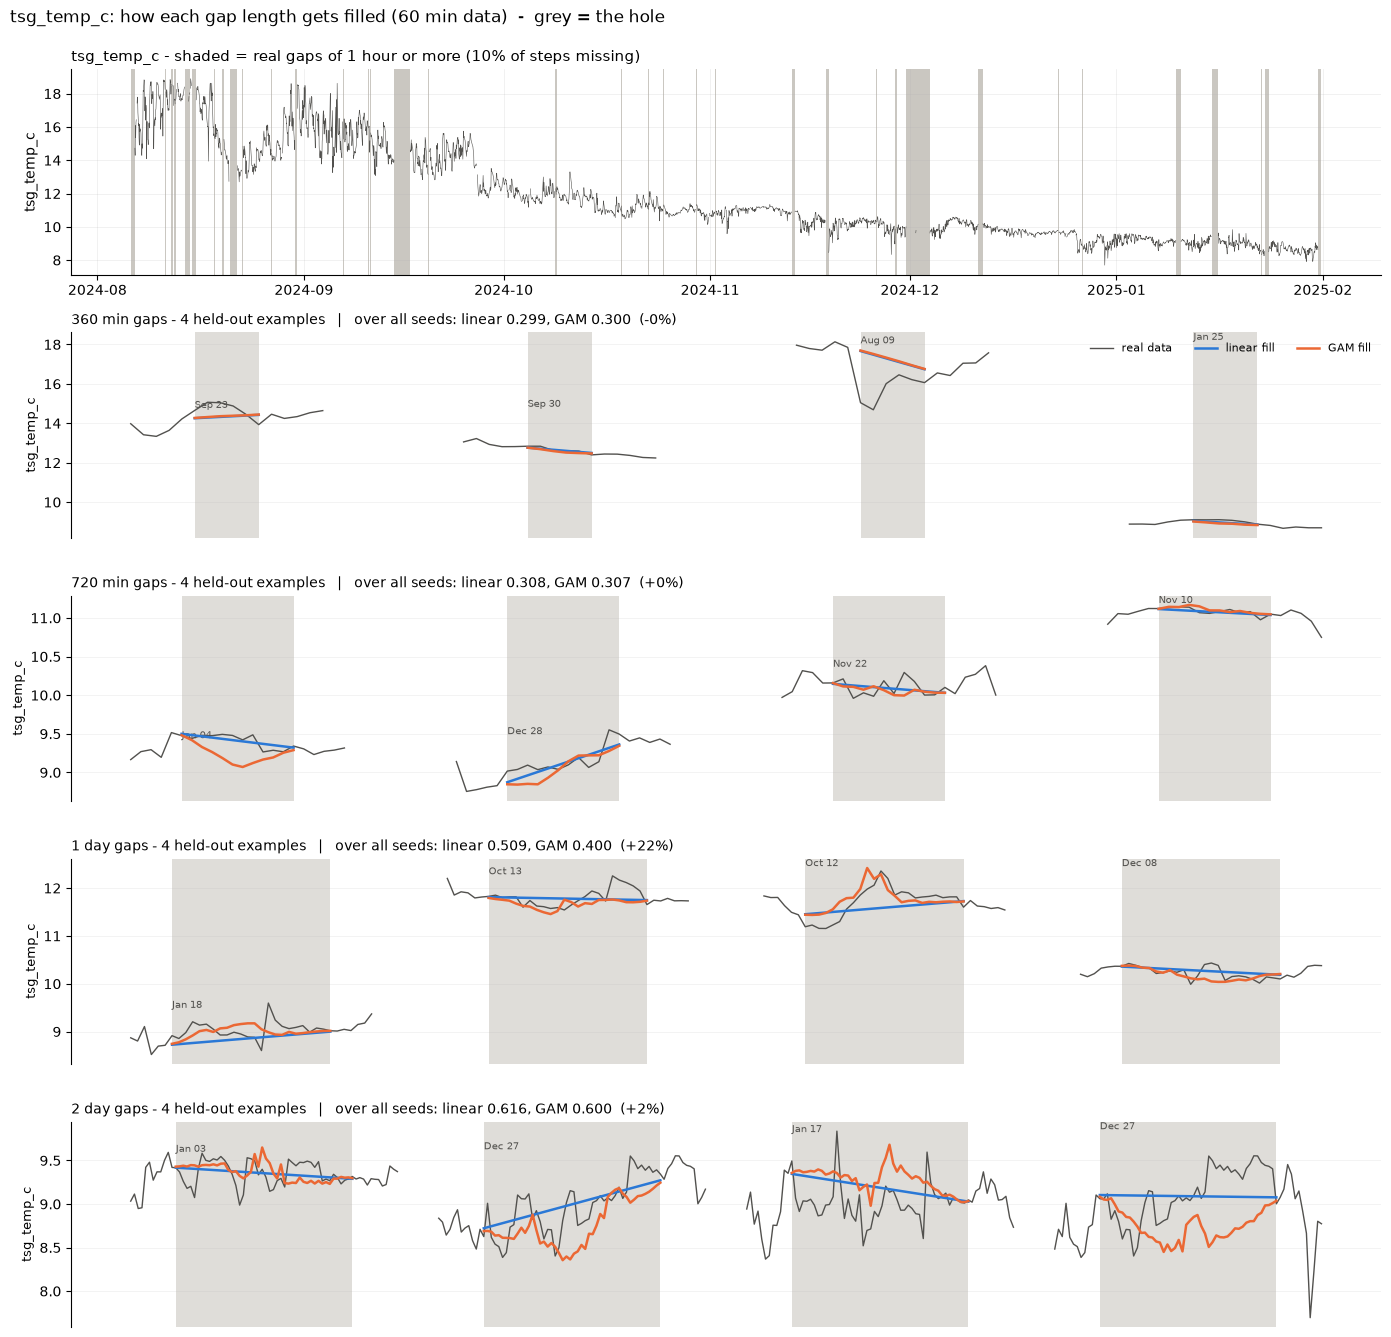

In [26]:
# =====================================================================
# PER-HOUR gap fill.  Same call, same gap lengths in MINUTES - anything
# shorter than one hour is skipped automatically.
# =====================================================================
fit_hr = run_gapfill(dfh, target='tsg_temp_c',
                     gaps_min=(10, 60, 360, 720, 1440, 2880),
                     seeds=(0, 1, 2))

plot_gapfill(fit_hr, n_examples=4)


salinity_psu: 179 days at 1 min (257466 rows)
  drivers skipped: tide (no column)
  drivers used: hour, doy, airt, wind, wind_u, wind_v, press, par, rh
  2 blocks of 90 days (need 2 to score), pad 180 steps, lam 1000

ACCURACY  (RMSE, mean over seeds; lower is better)
         seeds   gaps  src_blk  test_blk  linear  lin_sd     gam  gam_sd  improve_%       real?
gap_min                                                                                        
10           3  150.0      2.0       1.0  0.1865  0.0203  0.2146  0.0170      -15.1  NO - noise
60           3  150.0      2.0       1.0  0.3998  0.0752  0.4372  0.0669       -9.4  NO - noise
360          3  150.0      2.0       1.0  0.8257  0.0417  0.9040  0.0644       -9.5  NO - noise
720          3  150.0      2.0       1.0  1.0274  0.2019  1.0937  0.1684       -6.5  NO - noise
1440         3  150.0      2.0       1.0  0.8564  0.4560  1.2665  0.9975      -47.9  NO - noise
2880         3  150.0      2.0       1.0  1.5687  0.8566  2

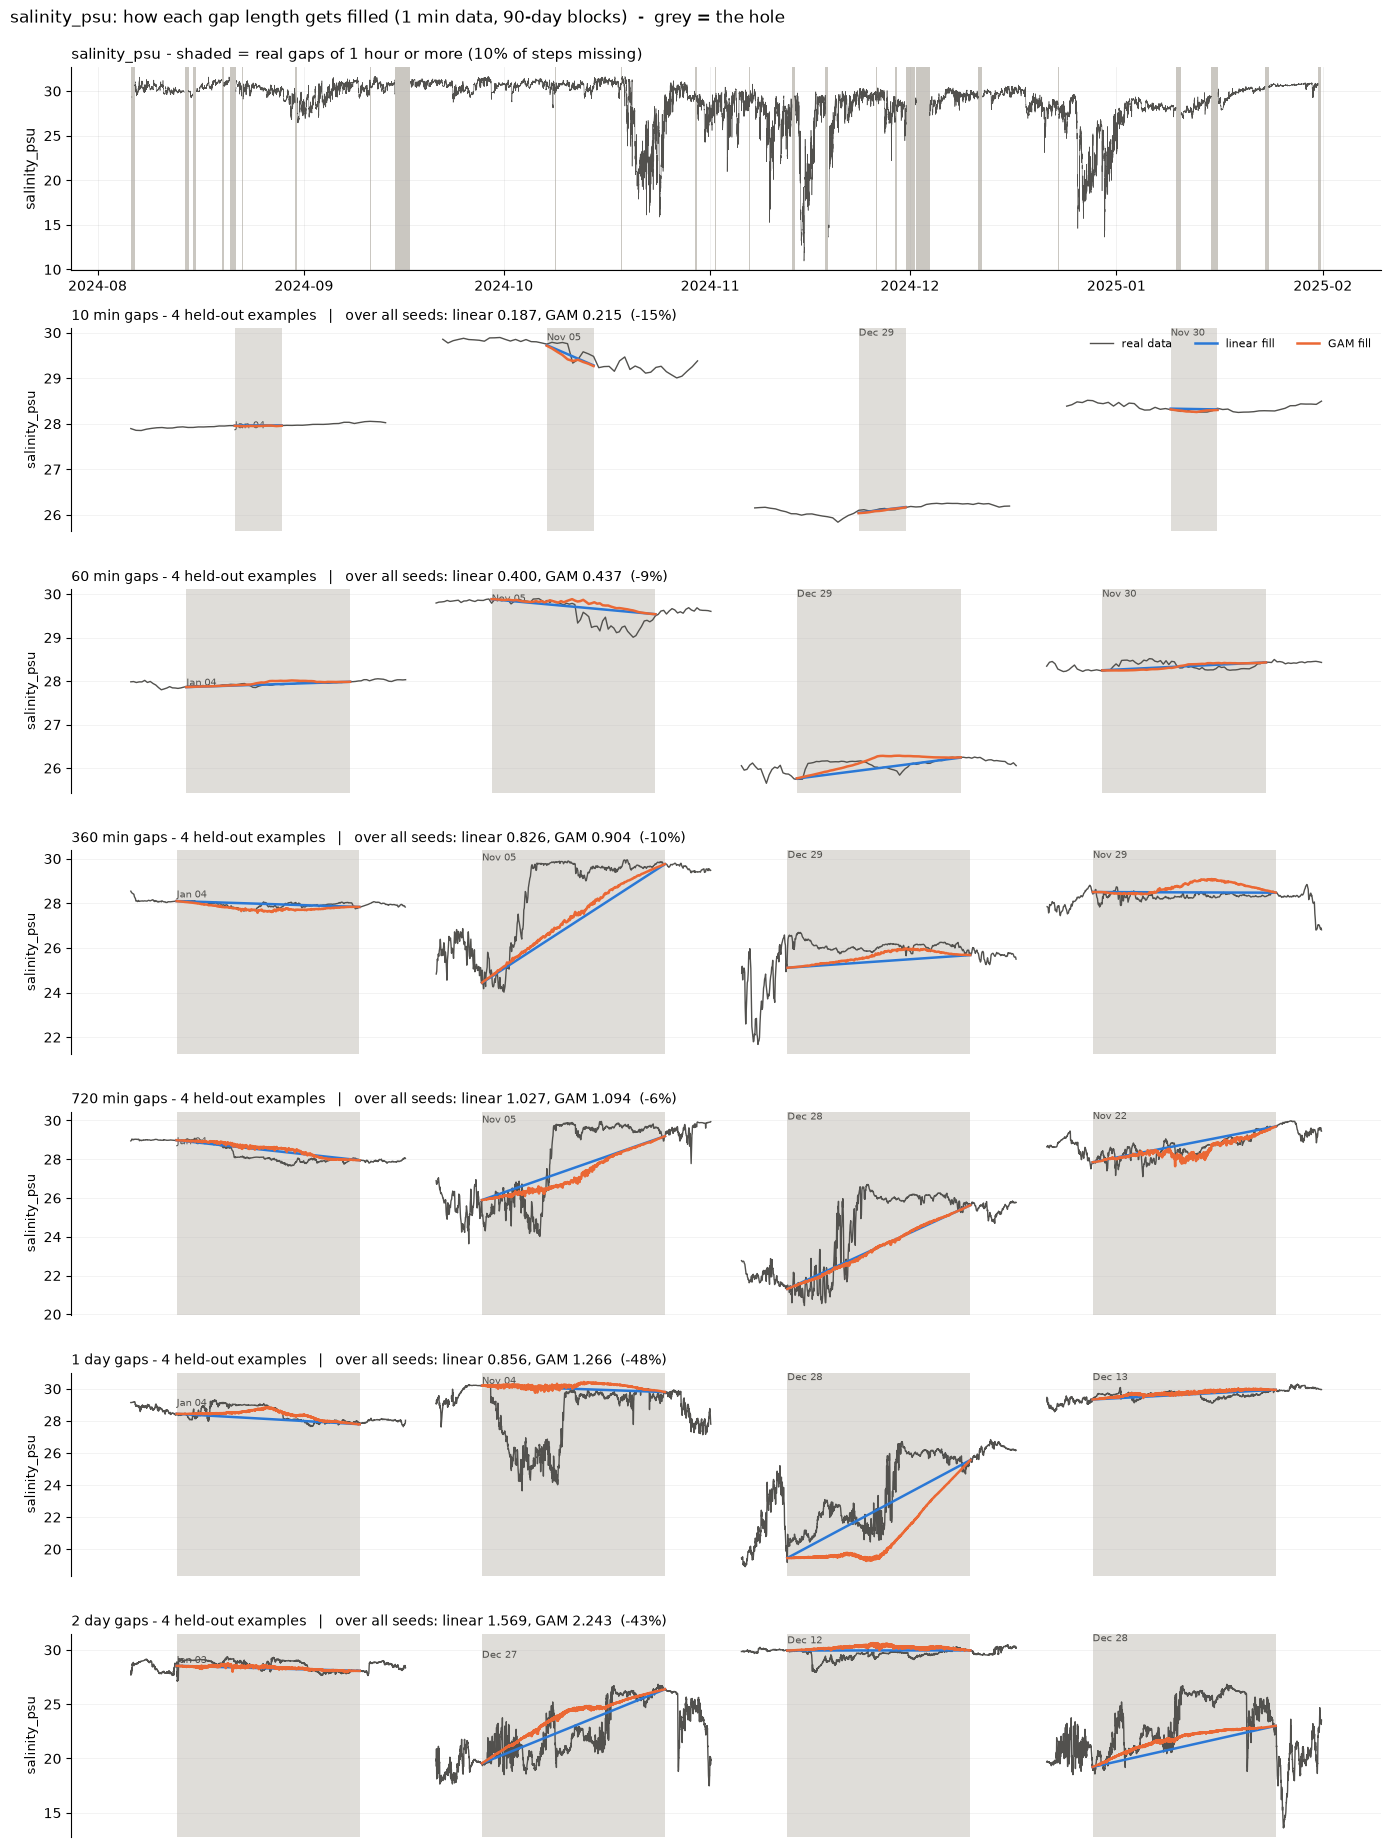

salinity_psu: 179 days at 60 min (4292 rows)
  drivers skipped: tide (no column)
  drivers used: hour, doy, airt, wind, wind_u, wind_v, press, par, rh
  2 blocks of 90 days (need 2 to score), pad 12 steps, lam 1000
  gap    10 min: shorter than one step - skipped
  gap    60 min: not enough clean stretches, or they span fewer than 2 blocks - skipped

ACCURACY  (RMSE, mean over seeds; lower is better)
         seeds   gaps  src_blk  test_blk  linear  lin_sd     gam  gam_sd  improve_%       real?
gap_min                                                                                        
360          3  150.0      2.0       1.0  0.8618  0.2050  0.8817  0.1628       -2.3  NO - noise
720          3  150.0      2.0       1.0  0.8072  0.1052  1.2944  0.5660      -60.3  NO - noise
1440         3  150.0      2.0       1.0  0.9035  0.3033  0.9818  0.3132       -8.7  NO - noise
2880         3  150.0      2.0       1.0  1.2728  0.5609  1.5413  0.2584      -21.1  NO - noise

SPREAD    (within-g

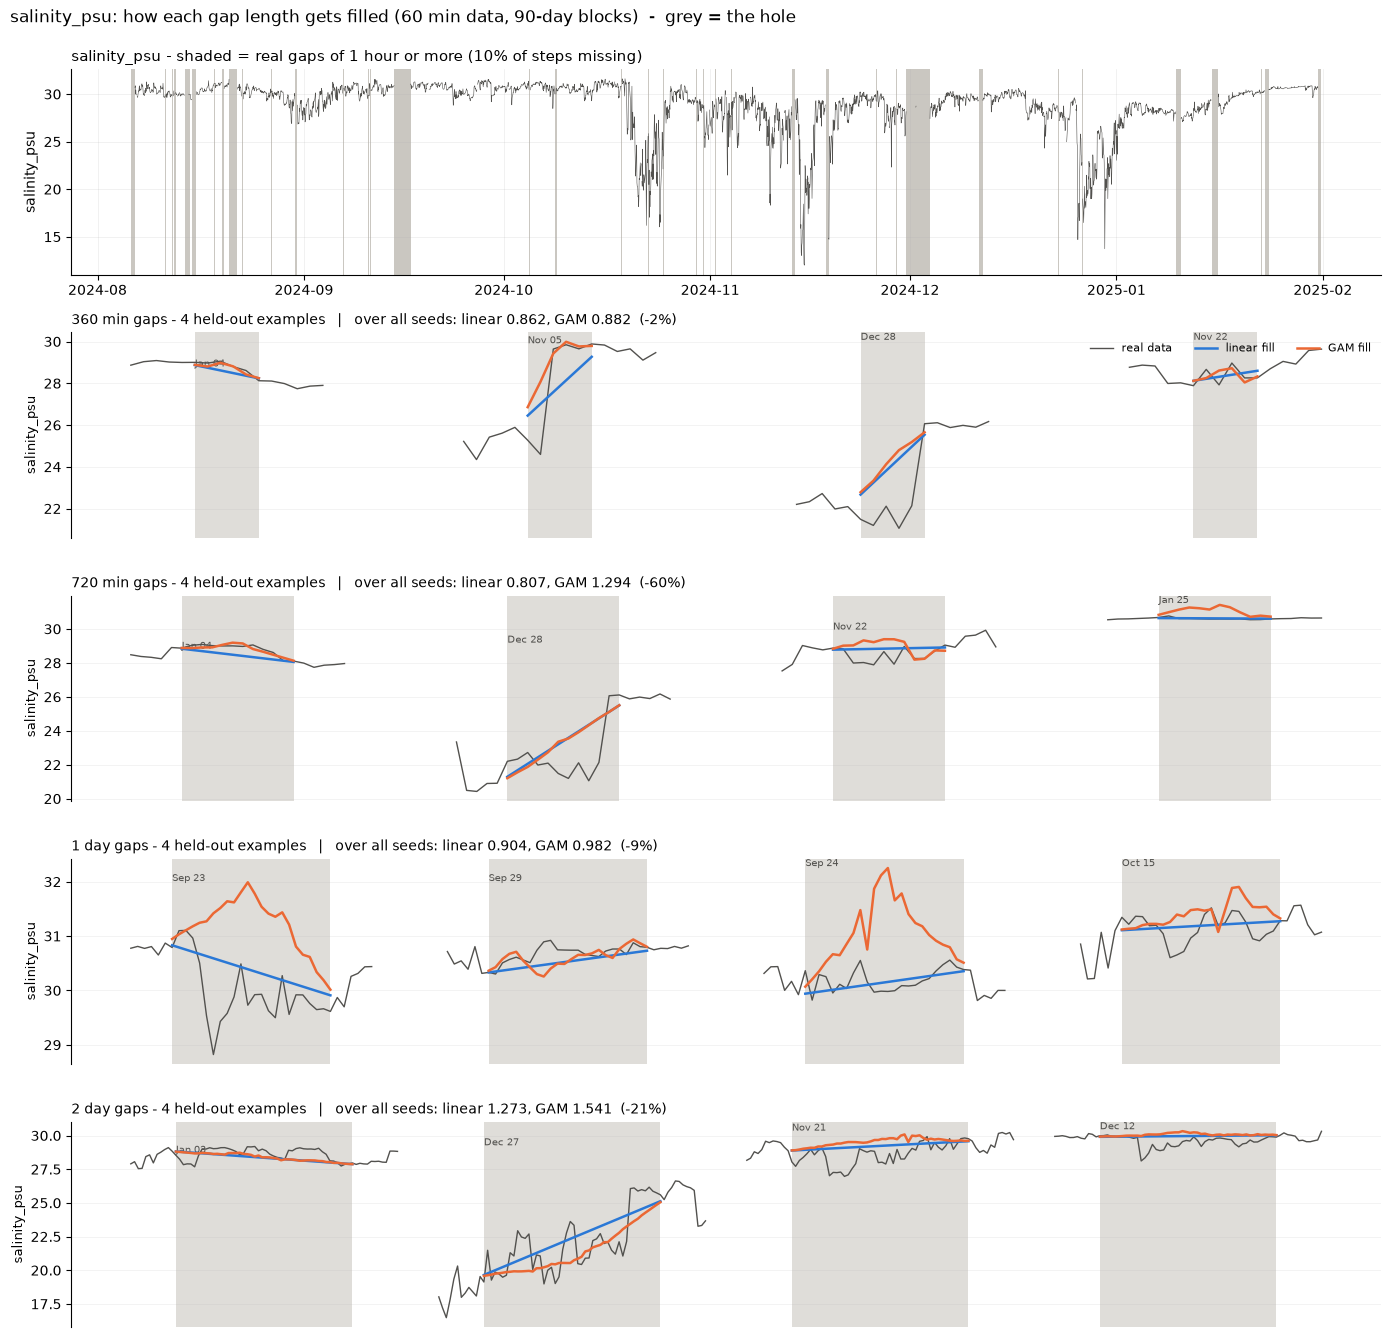

In [29]:
# =====================================================================
# SAME RUN, 3-MONTH BLOCKS instead of 2-week ones.
#
# The blocks decide which fake gaps train the GAM and which ones test it.
# Bigger blocks = train and test sit further apart in time, so the model
# can't score well just by recalling "same week, same weather" - it is a
# STRICTER test, not a leakier one.
#
# The catch: the record is only ~179 days, so 90-day blocks give just 2
# of them (train on one half, test on the other). That is below the
# usual min_blocks=4 guard, so it has to be lowered or every gap length
# skips. With only 2 blocks the score is also seasonal - you are asking
# "can a model fit on Aug-Nov fill gaps in Nov-Feb", which is a harder
# and much noisier question than the 2-week version.
# =====================================================================
fit_min_90 = run_gapfill(df, target='salinity_psu',
                         gaps_min=(10, 60, 360, 720, 1440, 2880),
                         seeds=(0, 1, 2),
                         block_days=90, min_blocks=2)

plot_gapfill(fit_min_90, n_examples=4)

fit_hr_90 = run_gapfill(dfh, target='salinity_psu',
                        gaps_min=(10, 60, 360, 720, 1440, 2880),
                        seeds=(0, 1, 2),
                        block_days=90, min_blocks=2)

plot_gapfill(fit_hr_90, n_examples=4)


In [23]:
# =====================================================================
# DOES CHINA CREEK HELP?
#
# Join the two records into one hourly frame, then run the gap-filler
# twice on it: once with the China Creek columns withheld, once with
# them allowed. Everything else - seeds, blocks, gap lengths - is held
# fixed, and the withheld run still REQUIRES China Creek to be present
# (use_drivers only controls what the GAM sees, not which gaps qualify).
# So both runs punch holes in exactly the same places and the only
# thing that changed is the two new columns.
# =====================================================================
# dfhc = dfh.join(cch.reindex(dfh.index))

print(f'joined frame: {dfhc.shape[0]} hourly rows, {dfhc.shape[1]} columns')
print('China Creek coverage:',
      dfhc[['cc_temp_c', 'cc_salinity']].notna().mean().round(3).to_dict())

# how well the two sites even track each other, before asking the GAM
print('\ncorrelation with the PEARL series (hourly, overlapping rows):')
print(dfhc[['tsg_temp_c', 'salinity_psu', 'cc_temp_c', 'cc_salinity']]
      .corr().loc[['cc_temp_c', 'cc_salinity'],
                  ['tsg_temp_c', 'salinity_psu']].round(3).to_string())

BASE = ['hour', 'doy', 'airt', 'wind', 'wind_u', 'wind_v', 'press', 'par', 'rh']
WITH_CC = BASE + ['cc_temp', 'cc_sal']

GAPS = (360, 720, 1440, 2880)     # 6 h, 12 h, 1 day, 2 days
SEEDS_AB = (0, 1, 2)

runs = {}
for target in ('tsg_temp_c', 'salinity_psu'):
    for tag, drv in (('base', BASE), ('cc', WITH_CC)):
        label = 'WITHOUT China Creek' if tag == 'base' else 'WITH China Creek'
        print(f'\n{"="*72}\n{target}   -   {label}\n{"="*72}')
        runs[(target, tag)] = run_gapfill(dfhc, target=target, gaps_min=GAPS,
                                          seeds=SEEDS_AB, use_drivers=drv)


joined frame: 4265 hourly rows, 16 columns
China Creek coverage: {'cc_temp_c': 1.0, 'cc_salinity': 1.0}

correlation with the PEARL series (hourly, overlapping rows):
             tsg_temp_c  salinity_psu
cc_temp_c        -0.889        -0.262
cc_salinity       0.719         0.171

tsg_temp_c   -   WITHOUT China Creek
tsg_temp_c: 178 days at 60 min (4265 rows)
  drivers skipped: tide (no column)
  drivers used: hour, doy, airt, wind, wind_u, wind_v, press, par, rh
  drivers withheld from the model, but still required present: cc_temp, cc_sal
  13 blocks of 14 days (need 4 to score), pad 12 steps, lam 1000

ACCURACY  (RMSE, mean over seeds; lower is better)
         seeds   gaps  src_blk  test_blk  linear  lin_sd     gam  gam_sd  improve_%       real?
gap_min                                                                                        
360          3  150.0  12.6667       4.0  0.3101  0.1409  0.3344  0.1468       -7.9  NO - noise
720          3  150.0  12.6667       4.0  0.5491

In [24]:
# ---- side-by-side scoreboard ----------------------------------------
# `lift_%` is how much the two China Creek columns cut the GAM's error.
# `real?` compares that change against the seed-to-seed wobble of the two
# runs - anything inside that band is the random seed talking, not the
# new drivers.
rows = []
for target in ('tsg_temp_c', 'salinity_psu'):
    b, c = runs[(target, 'base')].summary, runs[(target, 'cc')].summary
    for g in b.index.intersection(c.index):
        noise = float(np.nan_to_num(b.loc[g, 'gam_sd']) + np.nan_to_num(c.loc[g, 'gam_sd']))
        rows.append(dict(
            target=target, gap_min=g,
            linear=b.loc[g, 'linear'],
            gam_base=b.loc[g, 'gam'], gam_cc=c.loc[g, 'gam'],
            lift_pct=round(100 * (b.loc[g, 'gam'] - c.loc[g, 'gam']) / b.loc[g, 'gam'], 1),
            seed_noise=round(noise, 4),
            beats_linear='yes' if c.loc[g, 'gam'] < b.loc[g, 'linear'] else 'no'))
        rows[-1]['real?'] = ('yes' if abs(b.loc[g, 'gam'] - c.loc[g, 'gam']) > noise
                             else 'NO - noise')

cmp = pd.DataFrame(rows)
print('CHINA CREEK LIFT  (positive lift_% = the new drivers reduced RMSE)')
print(cmp.round(4).to_string(index=False))


CHINA CREEK LIFT  (positive lift_% = the new drivers reduced RMSE)
      target  gap_min  linear  gam_base  gam_cc  lift_pct  seed_noise beats_linear      real?
  tsg_temp_c      360  0.3101    0.3344  0.3453      -3.2      0.2906           no NO - noise
  tsg_temp_c      720  0.5491    0.5368  0.5379      -0.2      0.4839          yes NO - noise
  tsg_temp_c     1440  0.5933    0.4587  0.4613      -0.6      0.1702          yes NO - noise
  tsg_temp_c     2880  0.7952    0.7429  0.7506      -1.0      0.8427          yes NO - noise
salinity_psu      360  0.9322    0.8269  0.8569      -3.6      0.6401          yes NO - noise
salinity_psu      720  1.2970    1.2858  1.2917      -0.5      0.1035          yes NO - noise
salinity_psu     1440  0.8256    0.8873  0.9044      -1.9      1.1158           no NO - noise
salinity_psu     2880  1.3643    1.2535  1.2559      -0.2      1.0470          yes NO - noise



tsg_temp_c  —  WITHOUT China Creek


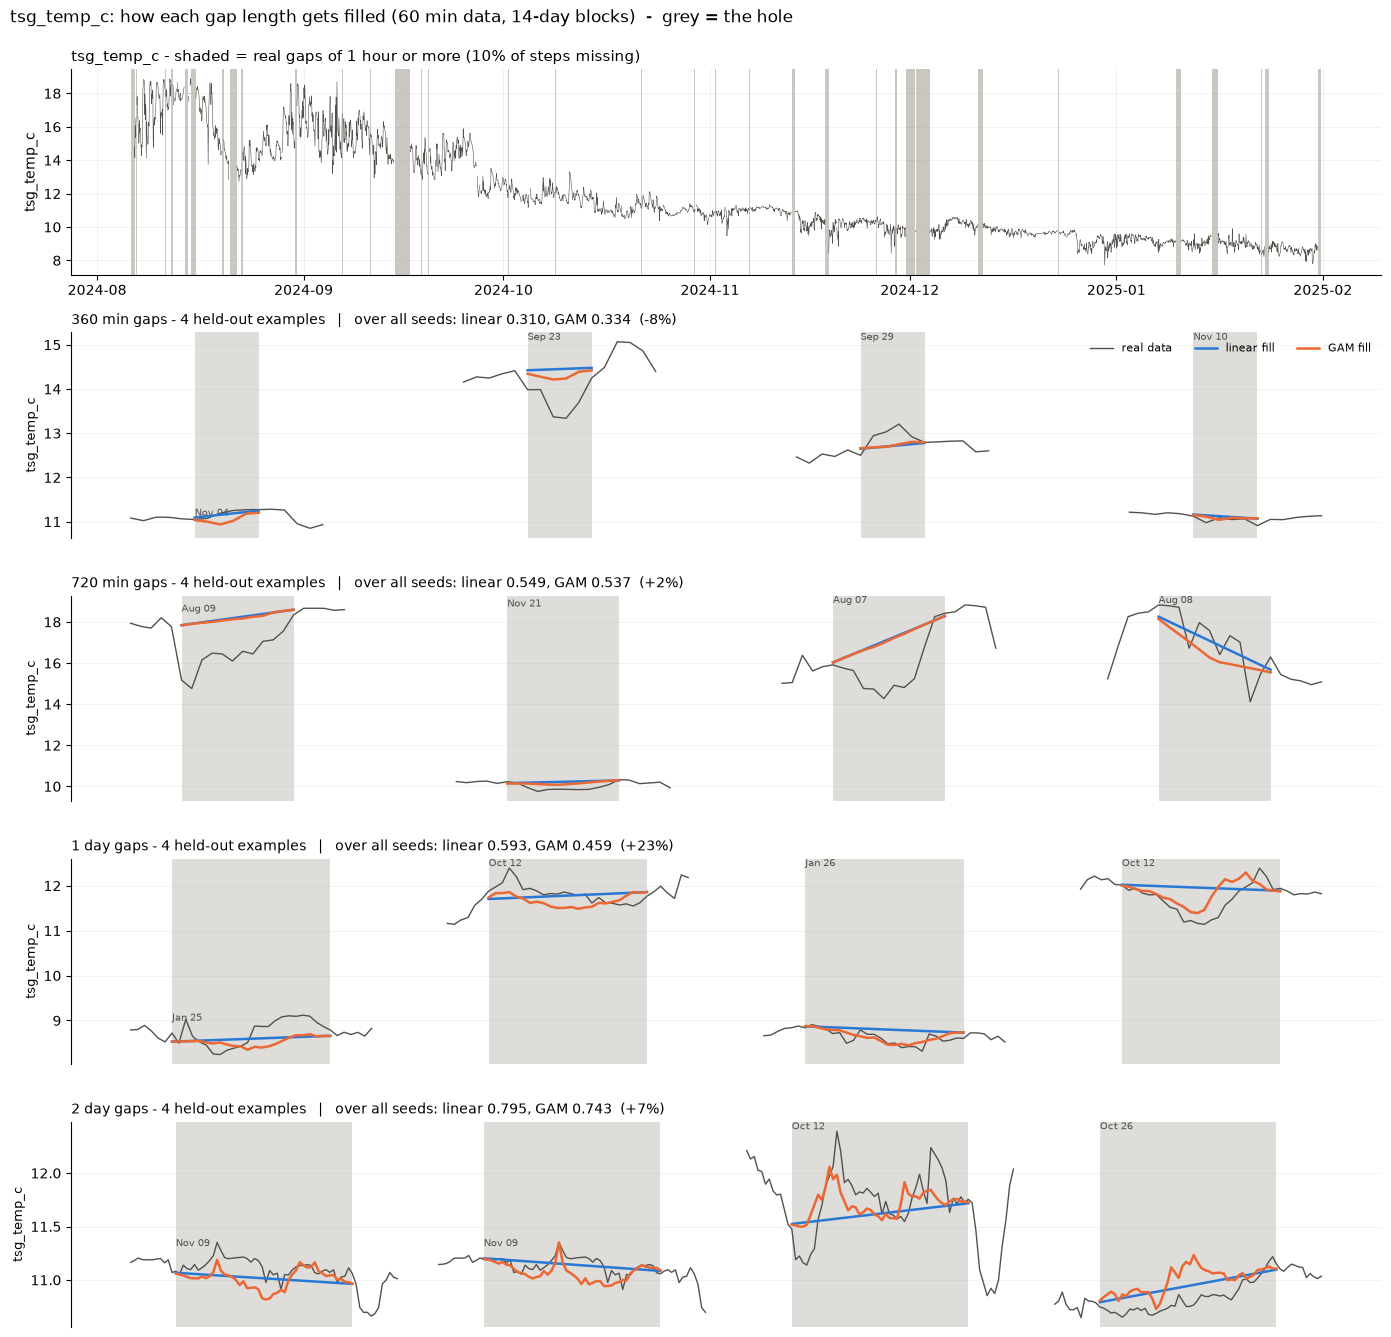


tsg_temp_c  —  WITH China Creek


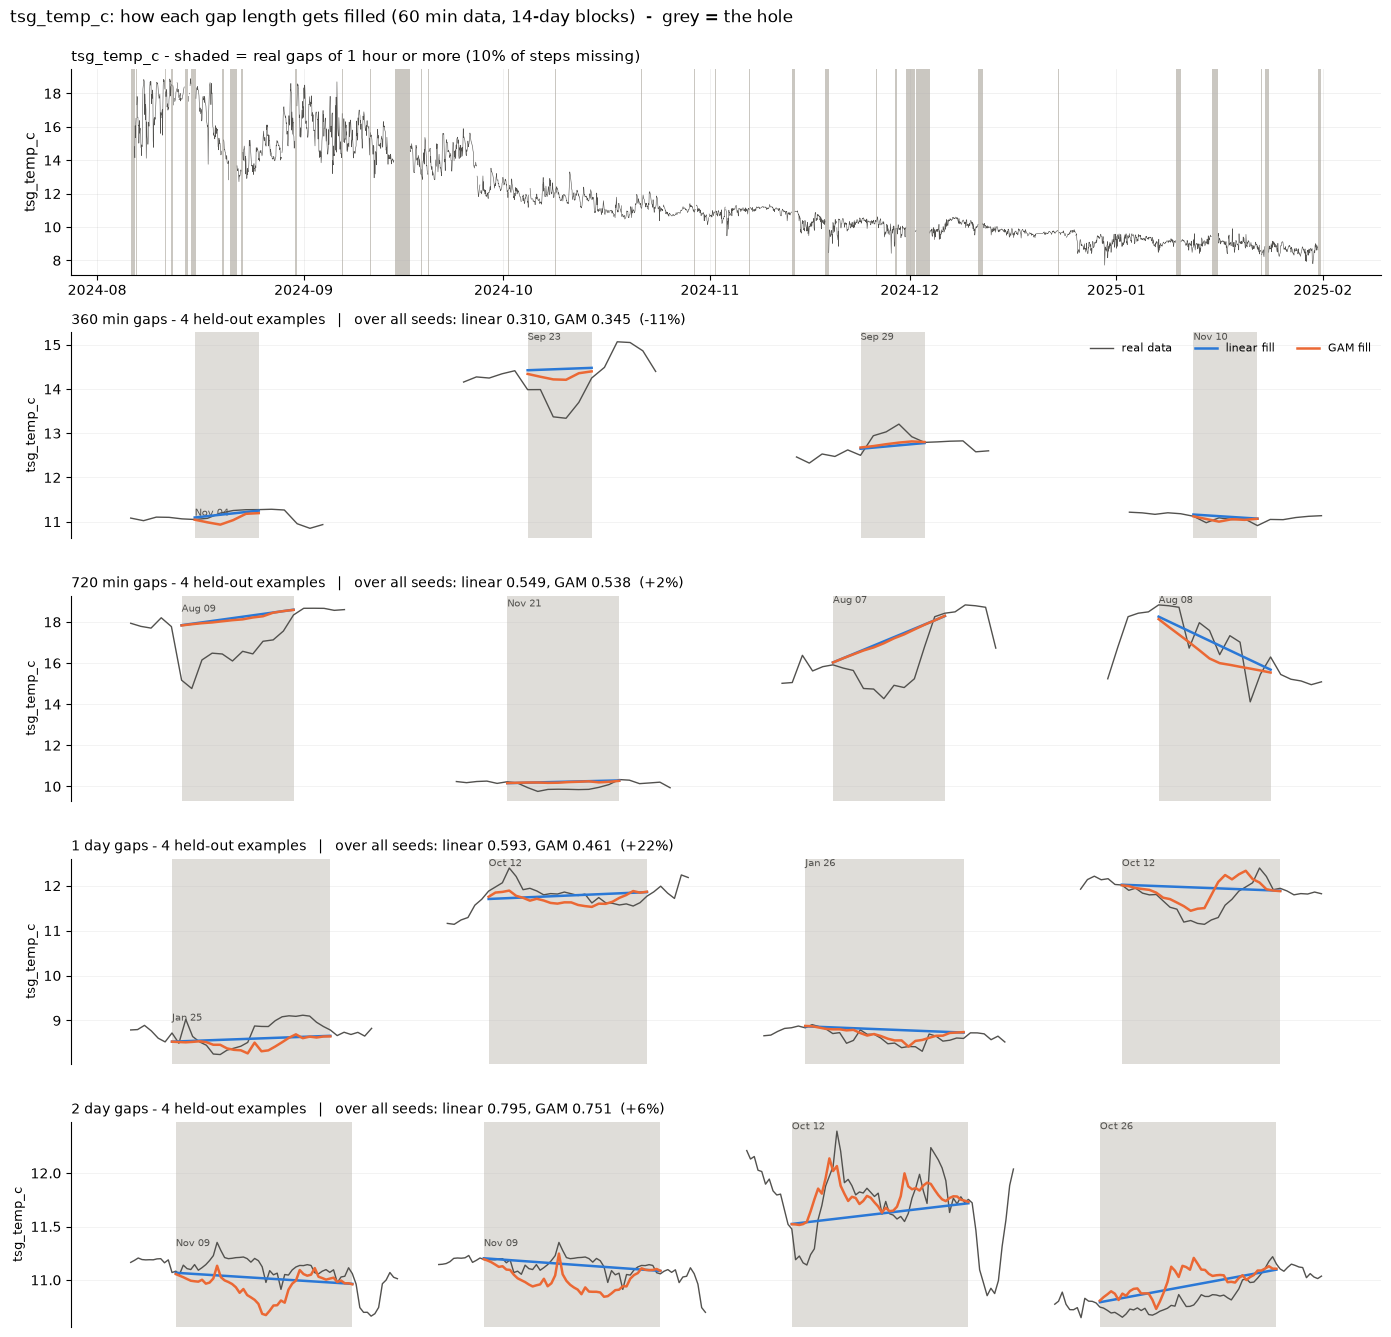


salinity_psu  —  WITHOUT China Creek


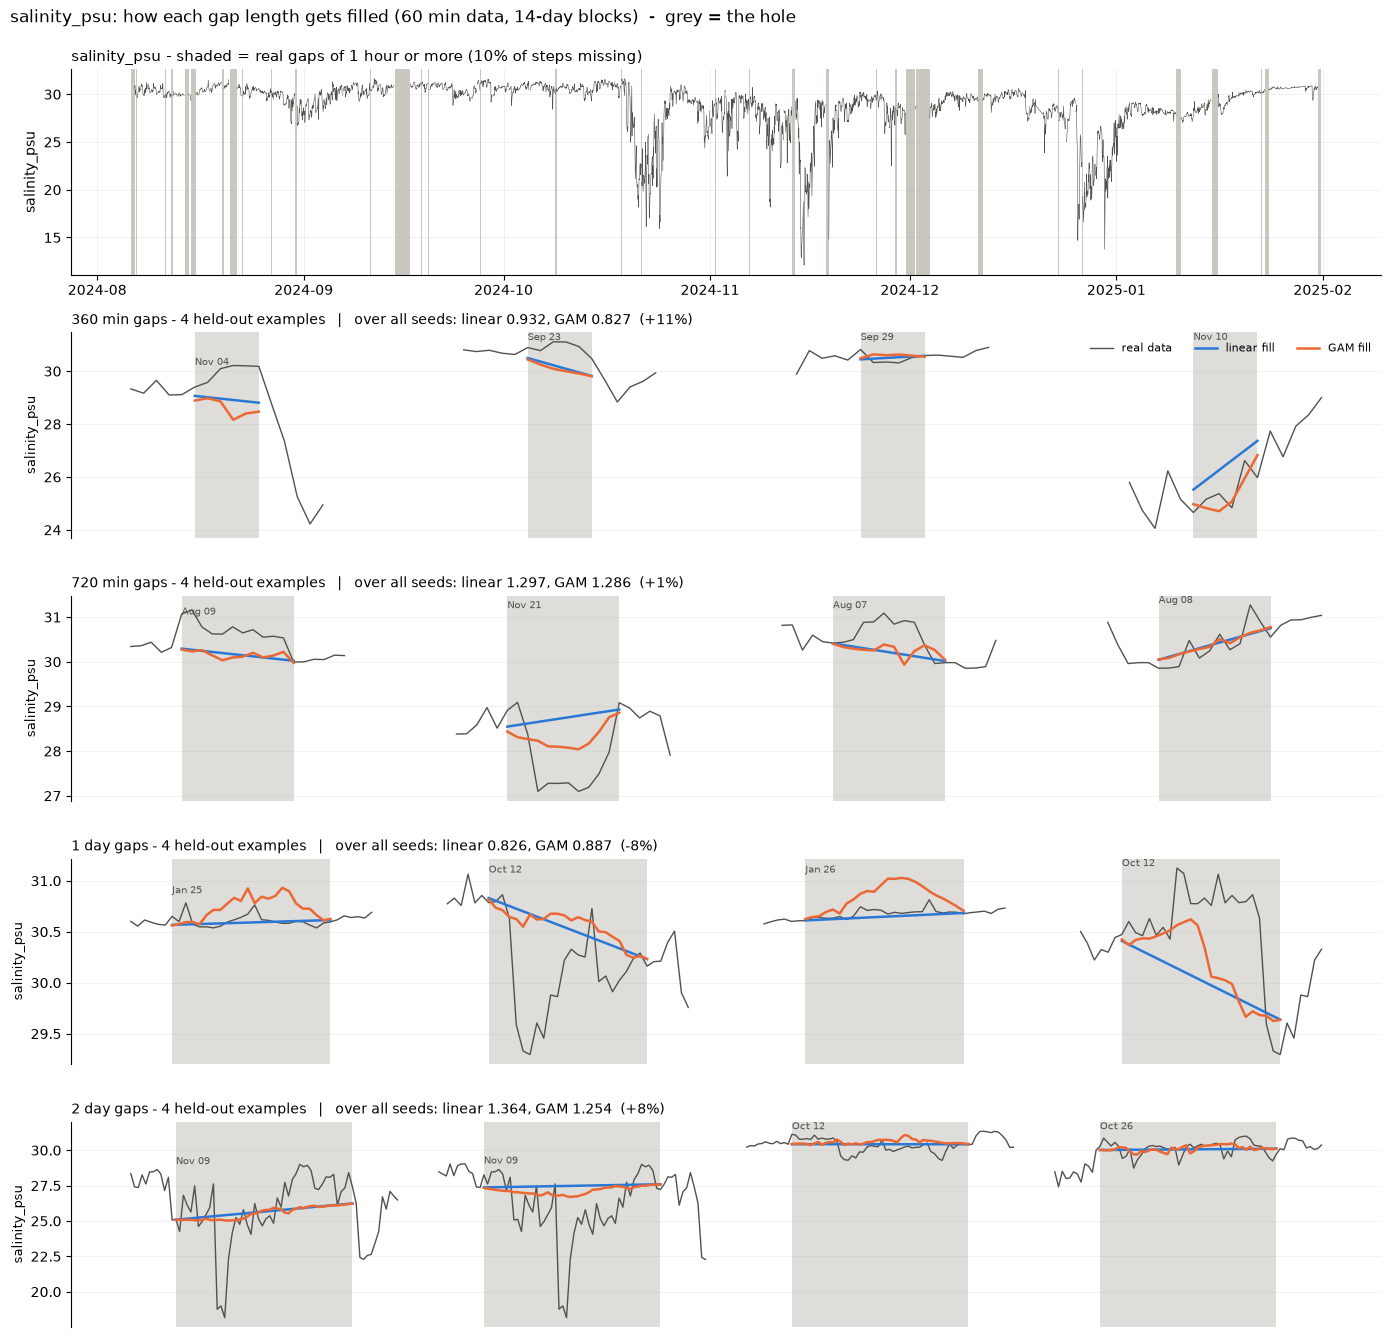


salinity_psu  —  WITH China Creek


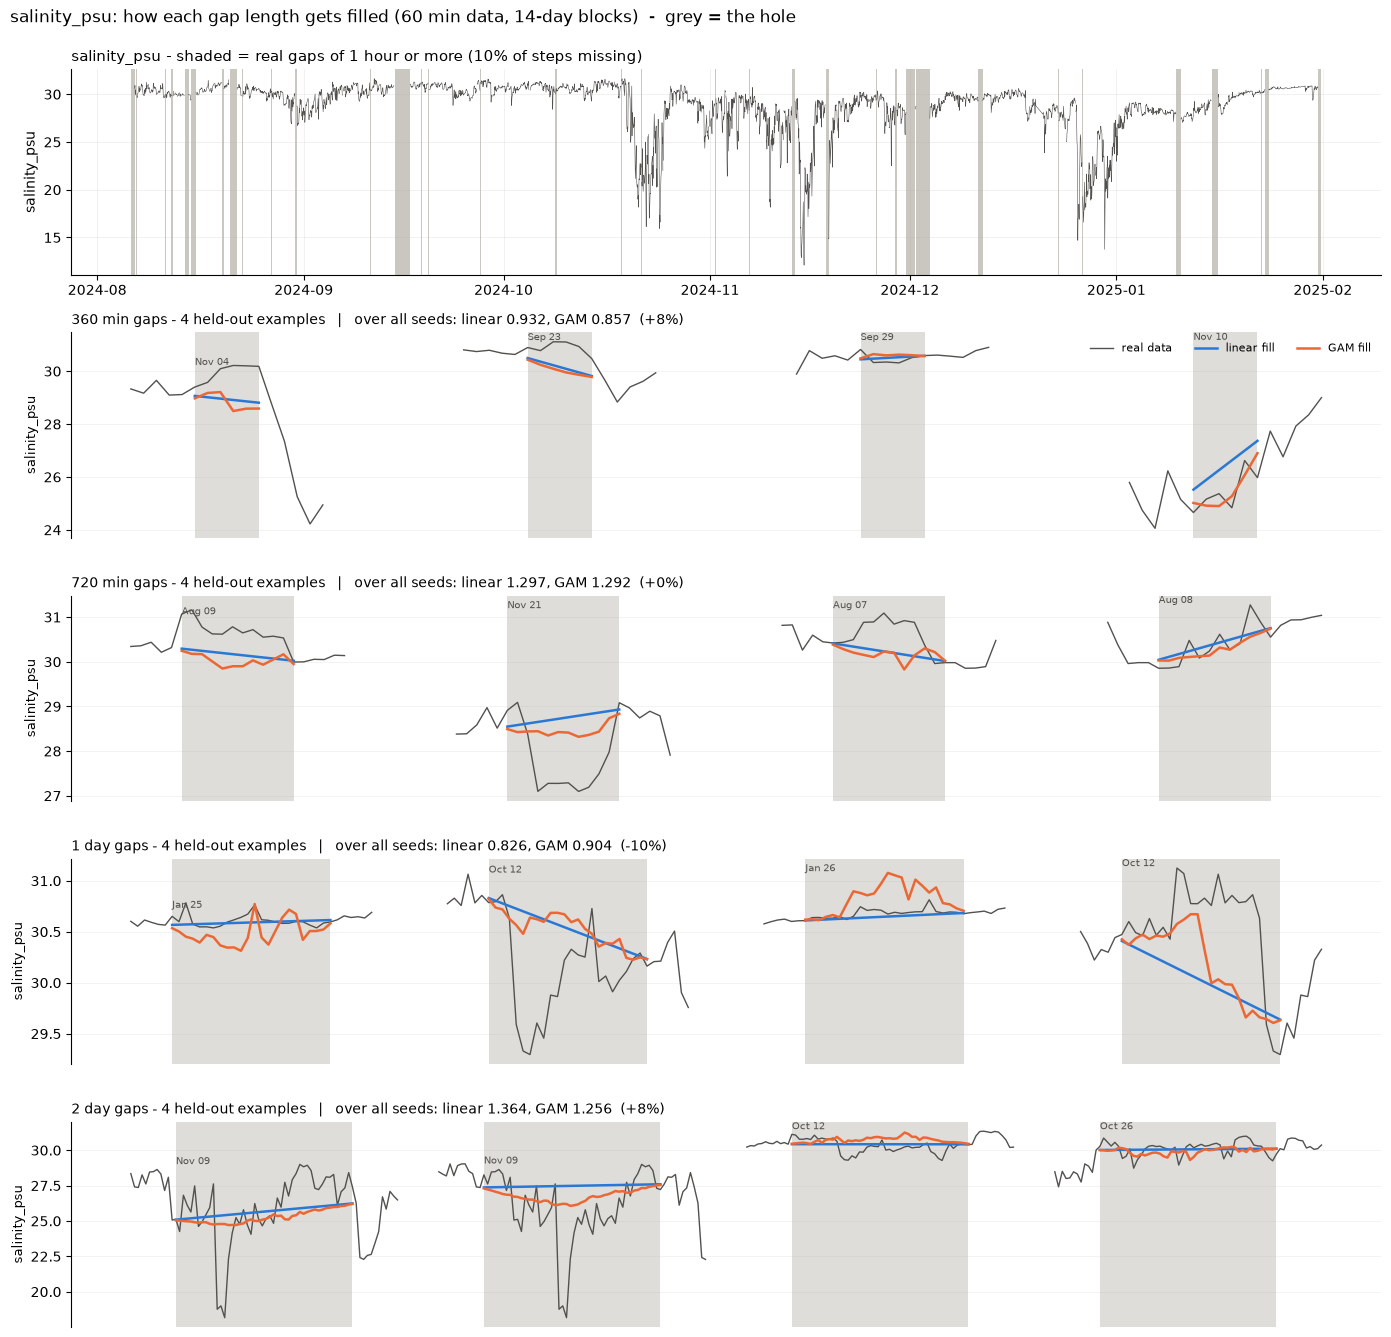

In [26]:
for (target, tag), fit in runs.items():
    label = 'WITH China Creek' if tag == 'cc' else 'WITHOUT China Creek'
    print(f'\n{"="*72}\n{target}  —  {label}\n{"="*72}')
    plot_gapfill(fit, n_examples=4)

## EXPERIMENTATION

In [27]:
# =====================================================================
# 1. reconstruct_series - tile the record with back-to-back fake gaps,
#    fill each, stitch together. This IS the gap-filler, run everywhere,
#    so you see where it tracks the record and where it drifts.
# 2. driver_gam - a DIFFERENT, plain GAM: value ~ drivers, no gap
#    structure. This one can predict the whole record, and answers
#    "do the drivers alone capture the seasonal pattern?"
# =====================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pygam import LinearGAM, s


def reconstruct_series(fit, gap_min):
    """Fill the whole record with consecutive gaps of one length."""
    if gap_min not in fit.models:
        print(f'no model for {gap_min} min'); return None
    gam, cols, _ = fit.models[gap_min]
    G = gap_min // fit.freq_min
    gam_out = np.full(len(fit.y), np.nan)
    lin_out = np.full(len(fit.y), np.nan)
    i = fit.pad
    while i + G + fit.pad < len(fit.y):
        w = slice(i - fit.pad, i + G + fit.pad)
        if fit.y_ok[w].all() and fit.ext_ok[w].all():
            f = gap_rows(fit, i, G, np.arange(G))
            tp = taper(f.pos_frac.values)
            lin_out[i:i+G] = f.linear_guess.values
            gam_out[i:i+G] = f.linear_guess.values + gam.predict(f[cols].values) * tp
        i += G
    return gam_out, lin_out


def driver_gam(fit, lam=100, stride=5):
    """Plain GAM: target ~ drivers only. Predicts the whole record."""
    cols = fit.use_names
    idx = [fit.driver_names.index(c) for c in cols]
    X = fit.ext[:, idx]
    ok = fit.y_ok & fit.ext_ok
    terms = None
    for k, c in enumerate(cols):
        try:
            t = s(k, basis='cp') if c in CYCLIC else s(k)
        except Exception:
            t = s(k)
        terms = t if terms is None else terms + t
    g = LinearGAM(terms, lam=lam).fit(X[ok][::stride], fit.y[ok][::stride])
    pred = np.full(len(fit.y), np.nan)
    pred[fit.ext_ok] = g.predict(X[fit.ext_ok])
    r = np.sqrt(np.nanmean((fit.y[ok] - pred[ok]) ** 2))
    print(f'{fit.target}: driver-only GAM RMSE {r:.3f} '
          f'(record sd {np.nanstd(fit.y):.3f}) using {", ".join(cols)}')
    return g, pred


def plot_wide(fit, gap_min=1440, show_driver_gam=True, resample=None):
    """Zoomed-out: truth vs tiled gap-fill vs driver-only GAM."""
    rec = reconstruct_series(fit, gap_min)
    if rec is None: return
    gam_out, lin_out = rec
    series = {'real data': fit.y, 'tiled linear': lin_out, 'tiled GAM': gam_out}
    if show_driver_gam:
        series['driver-only GAM'] = driver_gam(fit)[1]

    if resample:
        idx = fit.index
        series = {k: pd.Series(v, index=idx).resample(resample).mean()
                  for k, v in series.items()}
        x = list(series.values())[0].index
        series = {k: v.values for k, v in series.items()}
    else:
        x = fit.index

    styles = {'real data':       dict(color=C['truth'], lw=0.7, zorder=4),
              'tiled linear':    dict(color=C['lin'],   lw=0.7, zorder=2, alpha=0.8),
              'tiled GAM':       dict(color=C['gam'],   lw=0.7, zorder=3, alpha=0.8),
              'driver-only GAM': dict(color='#1baf7a',  lw=0.9, zorder=1, alpha=0.7)}

    fig, ax = plt.subplots(figsize=(14, 4.5))
    for k, v in series.items():
        ax.plot(x, v, label=k, **styles[k])
    lbl = f'{gap_min} min' if gap_min < 1440 else f'{gap_min//1440} day'
    ax.set_title(f'{fit.target}: whole record, tiled with back-to-back {lbl} gaps',
                 loc='left', fontsize=11)
    ax.set_ylabel(fit.target)
    ax.legend(frameon=False, fontsize=9, ncol=4)
    ax.grid(alpha=0.25, lw=0.5)
    for sp_ in ('top', 'right'):
        ax.spines[sp_].set_visible(False)
    fig.tight_layout(); plt.show()

In [28]:
plot_wide(fit_hr, gap_min=1440)                    # temperature
plot_wide(fit_hr_sal, gap_min=1440)                # salinity
plot_wide(fit_hr, gap_min=1440, resample='1D')     # daily means, less clutter

NameError: name 'fit_hr' is not defined

In [29]:
def fill_ci(fit, gap_min, i, width=0.95):
    gam, cols, _ = fit.models[gap_min]
    G = gap_min // fit.freq_min
    f = gap_rows(fit, i, G, np.arange(G))
    tp = taper(f.pos_frac.values)
    lin = f.linear_guess.values
    pred = lin + gam.predict(f[cols].values) * tp
    iv = gam.prediction_intervals(f[cols].values, width=width)
    return (fit.index[i:i+G], f.truth.values, lin, pred,
            lin + iv[:, 0] * tp, lin + iv[:, 1] * tp)


def plot_examples_ci(fit, gap_min, ax, n_examples=4, errorbars=False, width=0.95):
    G = gap_min // fit.freq_min
    starts = [int(i) for i in fit.models[gap_min][2][:n_examples]]
    ctx, offset = max(20 // fit.freq_min, G // 4, 5), 0
    for n, i in enumerate(starts):
        if errorbars:
            _, truth, lin, gam, lo, hi = fill_ci(fit, gap_min, i, width)
        else:
            _, truth, lin, gam = fit.fill(gap_min, i); lo = hi = None
        seg = fit.y[i - ctx: i + G + ctx]
        x = np.arange(len(seg)) + offset
        xg = x[ctx:ctx + G]
        ax.axvspan(xg[0], xg[-1], color=C['gap'], alpha=0.45, lw=0, zorder=0)
        if lo is not None:
            ax.fill_between(xg, lo, hi, color=C['gam'], alpha=0.2, lw=0, zorder=1,
                            label=f'GAM {int(width*100)}% interval' if n == 0 else None)
        ax.plot(x, seg, lw=1.0, color=C['truth'], zorder=4,
                label='real data' if n == 0 else None)
        ax.plot(xg, lin, lw=1.8, color=C['lin'], zorder=5,
                label='linear fill' if n == 0 else None)
        ax.plot(xg, gam, lw=1.8, color=C['gam'], zorder=6,
                label='GAM fill' if n == 0 else None)
        ax.text(xg[0], ax.get_ylim()[1], fit.index[i].strftime('%b %d'),
                fontsize=7, color=C['truth'], va='top', ha='left')
        offset += len(seg) + max(10, G // 6)
    lbl = f'{gap_min} min' if gap_min < 1440 else f'{gap_min//1440} day'
    title = f'{lbl} gaps - {len(starts)} held-out examples'
    if gap_min in fit.summary.index:
        r = fit.summary.loc[gap_min]
        title += (f'   |   linear {r.linear:.3f}, GAM {r.gam:.3f}'
                  f'  ({r["improve_%"]:+.0f}%)')
    ax.set_title(title, loc='left', fontsize=10)
    ax.set_ylabel(fit.target, fontsize=9)
    ax.set_xticks([]); ax.grid(alpha=0.2, lw=0.5, axis='y')
    for sp_ in ('top', 'right', 'bottom'):
        ax.spines[sp_].set_visible(False)


def plot_gapfill2(fit, gaps_min=None, n_examples=4, errorbars=False,
                  width=0.95, note=''):
    show = [G for G in (gaps_min or fit.models.keys()) if G in fit.models]
    if not show:
        print('no fitted models to plot'); return
    fig, axes = plt.subplots(1 + len(show), 1,
                             figsize=(14, 3.2 + 2.6 * len(show)), squeeze=False)
    axes = axes[:, 0]
    plot_overview(fit, axes[0])
    for ax, G in zip(axes[1:], show):
        plot_examples_ci(fit, G, ax, n_examples, errorbars, width)
    axes[1].legend(loc='upper right', frameon=False, fontsize=8, ncol=4)
    axes[0].grid(alpha=0.25, lw=0.5)
    for sp_ in ('top', 'right'):
        axes[0].spines[sp_].set_visible(False)
    fig.suptitle(f'{fit.target}: how each gap length gets filled '
                 f'({fit.freq_min} min data, {fit.block_days}-day blocks{note})',
                 fontsize=12, x=0.01, ha='left')
    fig.tight_layout(rect=[0, 0, 1, 0.985]); plt.show()

In [30]:
plot_gapfill2(fit_hr, n_examples=4, errorbars=True)

NameError: name 'fit_hr' is not defined

## ONE GAM ACROSS LENGTH 

In [31]:
# =====================================================================
# POOLED GAM: one model across all gap lengths.
# Adds log(gap_len) so the model can scale its correction, uses one
# feature set throughout, and weights rows so long gaps don't drown
# out short ones. Scored per length so it drops into the same table.
# =====================================================================
def run_pooled(fit, train_lens=(10, 60, 180, 360, 720, 1440, 2880),
               test_lens=None, seed=0, n_gaps=120, lam=LAM):
    test_lens = test_lens or train_lens
    rng = np.random.default_rng(seed)
    drivers = fit.use_names + [f'd_{c}' for c in DELTA if c in fit.use_names]
    cols = SHAPE_COLS + LOCAL_COLS + ['log_gap'] + drivers

    def collect(lens):
        frames = []
        for G_min in lens:
            G = G_min // fit.freq_min
            if G < 1:
                continue
            for gid, i in enumerate(sample_starts(fit, G, rng, n_gaps)):
                ks = (np.arange(G) if G <= MAX_ROWS
                      else np.sort(rng.choice(G, MAX_ROWS, replace=False)))
                f = gap_rows(fit, i, G, ks)
                f['log_gap'] = np.log10(G_min)
                f['gap_min'], f['block'], f['start'] = G_min, fit.block[i], i
                f['gap_id'] = f'{G_min}_{gid}'
                frames.append(f)
        if not frames:
            return None
        return (pd.concat(frames, ignore_index=True)
                  .replace([np.inf, -np.inf], np.nan)
                  .dropna(subset=cols + ['truth', 'linear_guess']))

    ex = collect(sorted(set(train_lens) | set(test_lens)))
    if ex is None or len(ex) < 500:
        print('not enough data'); return None

    blocks = np.unique(ex.block.values)
    rng.shuffle(blocks)
    tr_b = set(blocks[:max(1, round(TRAIN_FRAC * len(blocks)))])
    tr = ex[ex.block.isin(tr_b) & ex.gap_min.isin(train_lens)]
    te = ex[~ex.block.isin(tr_b) & ex.gap_min.isin(test_lens)]
    if len(tr) < 300 or len(te) < 200:
        print('split too small'); return None

    # equalise: every gap length contributes the same total weight
    w = tr.groupby('gap_min').gap_min.transform('size')
    w = (len(tr) / (tr.gap_min.nunique() * w)).values

    terms = None
    for k, c in enumerate(cols):
        try:
            t = s(k, basis='cp') if c in CYCLIC else s(k)
        except Exception:
            t = s(k)
        terms = t if terms is None else terms + t

    gam = LinearGAM(terms, lam=lam).fit(
        tr[cols].values, (tr.truth - tr.linear_guess).values, weights=w)

    te = te.assign(pred=te.linear_guess.values
                        + gam.predict(te[cols].values) * taper(te.pos_frac.values))

    rows = []
    for G_min, sub in te.groupby('gap_min'):
        r = lambda a: float(np.sqrt(np.mean((sub.truth.values - a) ** 2)))
        rows.append(dict(gap_min=G_min, n=len(sub), n_gaps=sub.gap_id.nunique(),
                         seen_in_training=G_min in train_lens,
                         linear=r(sub.linear_guess.values),
                         gam=r(sub.pred.values)))
    out = pd.DataFrame(rows).set_index('gap_min')
    out['improve_%'] = (100 * (out.linear - out.gam) / out.linear).round(1)
    print(f'\nPOOLED - one GAM, {len(cols)} features, '
          f'{len(tr):,} train rows across {tr.gap_min.nunique()} lengths')
    print(out.round(4).to_string())
    return gam, cols, out

In [32]:
# train on the usual set, test on lengths it has never seen
run_pooled(fit_hr,
           train_lens=(60, 360, 1440),
           test_lens=(60, 90, 180, 360, 720, 1440, 2160))

NameError: name 'fit_hr' is not defined